# Restarted cascade Deep BSDE
Final numerical run for N=2 and 3


## Setup

In [1]:
from __future__ import annotations

import copy
import json
import math
import random
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch import Tensor, nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32
SEED = 123

RESULTS_DIR = Path.cwd() / "andreas_restart_n234_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Device", DEVICE)
if DEVICE.type == "cuda":
    print("GPU", torch.cuda.get_device_name(0))
print("Results directory", RESULTS_DIR.resolve())

Device cuda
GPU NVIDIA A100-SXM4-40GB
Results directory /content/andreas_restart_n234_results


In [2]:
@dataclass(frozen=True)
class Config:
    T: float = 1.0
    sigma: float = 1.0
    alpha: float = 1.0

    # Retained from the successful N=2 cascade notebook.
    x_min: float = 1.0
    x_max: float = 4.0
    singleton_x_min: float = 2.001
    max_restart_time: float = 0.95

    train_steps: int = 40
    restart_time_levels: int = 41

    width: int = 64
    depth: int = 3

    iterations_singleton: int = 15_000
    iterations_n2: int = 15_000
    batch_size: int = 1_024
    validation_size: int = 8_192

    learning_rate: float = 1.0e-3
    scheduler_step: int = 1_000
    scheduler_gamma: float = 0.95
    gradient_clip: float = 10.0
    validation_every: int = 200
    display_every: int = 1_000

    # Additional local conditions from the restarted construction.
    alive_state_weight: float = 0.10
    exit_step_weight: float = 0.10

    # Known qualitative constraints.
    singleton_nonincreasing_weight: float = 0.25
    higher_range_weight: float = 0.05

    # Post-training diagnostics only.
    validation_times: tuple[float, ...] = (0.00, 0.50, 0.90, 0.95)
    plot_grid: int = 181
    reference_grid: int = 51
    reference_paths: int = 2_048
    reference_steps: int = 400
    reference_point_batch: int = 32
    diagnostic_size: int = 4_096
    projection_samples: int = 4_096

CFG = Config()
print(CFG)

Config(T=1.0, sigma=1.0, alpha=1.0, x_min=1.0, x_max=4.0, singleton_x_min=2.001, max_restart_time=0.95, train_steps=40, restart_time_levels=41, width=64, depth=3, iterations_singleton=15000, iterations_n2=15000, batch_size=1024, validation_size=8192, learning_rate=0.001, scheduler_step=1000, scheduler_gamma=0.95, gradient_clip=10.0, validation_every=200, display_every=1000, alive_state_weight=0.1, exit_step_weight=0.1, singleton_nonincreasing_weight=0.25, higher_range_weight=0.05, validation_times=(0.0, 0.5, 0.9, 0.95), plot_grid=181, reference_grid=51, reference_paths=2048, reference_steps=400, reference_point_batch=32, diagnostic_size=4096, projection_samples=4096)


In [3]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_generator(seed: int) -> torch.Generator:
    generator = torch.Generator(device=DEVICE)
    generator.manual_seed(seed)
    return generator


def uniform(
    shape: tuple[int, ...],
    low: float,
    high: float,
    generator: torch.Generator,
) -> Tensor:
    return low + (high - low) * torch.rand(
        shape,
        generator=generator,
        device=DEVICE,
        dtype=DTYPE,
    )


def normal_cdf(value: Tensor) -> Tensor:
    return 0.5 * (1.0 + torch.erf(value / math.sqrt(2.0)))


def masked_mean(value: Tensor, mask: Tensor) -> Tensor:
    if bool(mask.any()):
        return value[mask].mean()
    return value.sum() * 0.0


def first_true_index(mask: Tensor) -> tuple[Tensor, Tensor]:
    hit = mask.any(dim=1)
    index = mask.to(torch.int64).argmax(dim=1)
    index = torch.where(
        hit,
        index,
        torch.full_like(index, mask.shape[1] - 1),
    )
    return index, hit


def time_column(
    t: float | Tensor,
    batch_size: int,
    *,
    device: torch.device,
    dtype: torch.dtype,
) -> Tensor:
    value = torch.as_tensor(t, device=device, dtype=dtype)
    if value.ndim == 0:
        value = value.expand(batch_size)
    return value.reshape(batch_size, 1)


def tensor_to_numpy(value: Tensor) -> np.ndarray:
    return value.detach().cpu().numpy()


def save_figure(fig: plt.Figure, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [4]:
class NormalisedMLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        width: int,
        depth: int,
        center: tuple[float, ...],
        scale: tuple[float, ...],
    ) -> None:
        super().__init__()

        self.register_buffer(
            "center",
            torch.tensor(center, dtype=DTYPE).reshape(1, -1),
        )
        self.register_buffer(
            "scale",
            torch.tensor(scale, dtype=DTYPE).reshape(1, -1),
        )

        layers: list[nn.Module] = []
        current = input_dim
        for _ in range(depth):
            layers.append(nn.Linear(current, width))
            layers.append(nn.Softplus())
            current = width
        layers.append(nn.Linear(current, output_dim))

        self.network = nn.Sequential(*layers)
        self.reset_parameters()

    def reset_parameters(self) -> None:
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x: Tensor) -> Tensor:
        return self.network((x - self.center) / self.scale)


class SingletonFBSDE(nn.Module):
    def __init__(self, cfg: Config) -> None:
        super().__init__()

        x_min = 2.0 * cfg.alpha
        x_max = cfg.x_max
        x_center = 0.5 * (x_min + x_max)
        x_scale = 0.5 * (x_max - x_min)

        self.value_net = NormalisedMLP(
            2,
            1,
            cfg.width,
            cfg.depth,
            center=(0.5, x_center),
            scale=(0.5, x_scale),
        )
        self.z_net = NormalisedMLP(
            2,
            1,
            cfg.width,
            cfg.depth,
            center=(0.5, x_center),
            scale=(0.5, x_scale),
        )

    def value(self, t: float | Tensor, x: Tensor) -> Tensor:
        x = x.reshape(-1)
        tc = time_column(
            t, x.shape[0], device=x.device, dtype=x.dtype
        )
        raw = self.value_net(
            torch.cat((tc, x[:, None]), dim=1)
        )[:, 0]

        # One particle has already been killed, so the aggregate field is
        # between one and two.
        return 1.0 + torch.sigmoid(raw)

    def z(self, t: float | Tensor, x: Tensor) -> Tensor:
        x = x.reshape(-1)
        tc = time_column(
            t, x.shape[0], device=x.device, dtype=x.dtype
        )
        return self.z_net(
            torch.cat((tc, x[:, None]), dim=1)
        )[:, 0]


class SymmetricTwoParticleFBSDE(nn.Module):
    def __init__(self, cfg: Config) -> None:
        super().__init__()

        x_center = 0.5 * (cfg.x_min + cfg.x_max)
        x_scale = 0.5 * (cfg.x_max - cfg.x_min)

        self.value_net = NormalisedMLP(
            3,
            1,
            cfg.width,
            cfg.depth,
            center=(0.5, x_center, 0.5 * x_scale**2),
            scale=(0.5, x_scale, 0.5 * x_scale**2),
        )
        self.z_component_net = NormalisedMLP(
            3,
            1,
            cfg.width,
            cfg.depth,
            center=(0.5, x_center, x_center),
            scale=(0.5, x_scale, x_scale),
        )

    def value(self, t: float | Tensor, x: Tensor) -> Tensor:
        tc = time_column(
            t, x.shape[0], device=x.device, dtype=x.dtype
        )
        mean = x.mean(dim=1, keepdim=True)
        half_gap_squared = 0.25 * (
            x[:, 0:1] - x[:, 1:2]
        ).square()

        return self.value_net(
            torch.cat((tc, mean, half_gap_squared), dim=1)
        )[:, 0]

    def z(self, t: float | Tensor, x: Tensor) -> Tensor:
        tc = time_column(
            t, x.shape[0], device=x.device, dtype=x.dtype
        )

        z1 = self.z_component_net(
            torch.cat((tc, x[:, 0:1], x[:, 1:2]), dim=1)
        )
        z2 = self.z_component_net(
            torch.cat((tc, x[:, 1:2], x[:, 0:1]), dim=1)
        )
        return torch.cat((z1, z2), dim=1)

In [5]:
@dataclass
class BrownianBatch:
    start_time: Tensor
    times: Tensor
    x0: Tensor
    paths: Tensor
    dW: Tensor


def stratified_restart_times(
    size: int,
    cfg: Config,
    generator: torch.Generator,
) -> Tensor:
    grid = torch.linspace(
        0.0,
        cfg.max_restart_time,
        cfg.restart_time_levels,
        device=DEVICE,
        dtype=DTYPE,
    )

    repeats = math.ceil(size / len(grid))
    values = grid.repeat(repeats)[:size]

    permutation = torch.randperm(
        size,
        generator=generator,
        device=DEVICE,
    )
    return values[permutation]


def sample_brownian_batch(
    *,
    batch_size: int,
    dimension: int,
    x_min: float,
    x_max: float,
    cfg: Config,
    generator: torch.Generator,
    antithetic: bool,
) -> BrownianBatch:
    if antithetic and batch_size % 2 != 0:
        raise ValueError("antithetic batch size must be even")

    base_size = batch_size // 2 if antithetic else batch_size

    start_time = stratified_restart_times(
        base_size, cfg, generator
    )

    x0 = uniform(
        (base_size, dimension),
        x_min,
        x_max,
        generator,
    )

    normals = torch.randn(
        base_size,
        cfg.train_steps,
        dimension,
        generator=generator,
        device=DEVICE,
        dtype=DTYPE,
    )

    if antithetic:
        start_time = torch.cat(
            (start_time, start_time.clone()), dim=0
        )
        x0 = torch.cat((x0, x0.clone()), dim=0)
        normals = torch.cat((normals, -normals), dim=0)

    dt = (cfg.T - start_time) / cfg.train_steps
    dW = torch.sqrt(dt)[:, None, None] * normals
    dX = cfg.sigma * dW

    zero = torch.zeros(
        batch_size,
        1,
        dimension,
        device=DEVICE,
        dtype=DTYPE,
    )

    paths = x0[:, None, :] + torch.cat(
        (zero, dX.cumsum(dim=1)),
        dim=1,
    )

    fraction = torch.arange(
        cfg.train_steps + 1,
        device=DEVICE,
        dtype=DTYPE,
    )[None, :] / cfg.train_steps

    times = (
        start_time[:, None]
        + (cfg.T - start_time)[:, None] * fraction
    )

    return BrownianBatch(
        start_time=start_time,
        times=times,
        x0=x0,
        paths=paths,
        dW=dW,
    )


def forward_singleton(
    model: SingletonFBSDE,
    batch: BrownianBatch,
    stop_index: Tensor,
) -> Tensor:
    y = model.value(
        batch.start_time,
        batch.x0[:, 0],
    )

    for k in range(batch.dW.shape[1]):
        in_current_level = (stop_index > k).to(DTYPE)
        z = model.z(
            batch.times[:, k],
            batch.paths[:, k, 0],
        )
        y = (
            y
            + in_current_level
            * z
            * batch.dW[:, k, 0]
        )

    return y


def forward_two_particle(
    model: SymmetricTwoParticleFBSDE,
    batch: BrownianBatch,
    stop_index: Tensor,
) -> Tensor:
    y = model.value(
        batch.start_time,
        batch.x0,
    )

    for k in range(batch.dW.shape[1]):
        in_current_level = (stop_index > k).to(DTYPE)
        z = model.z(
            batch.times[:, k],
            batch.paths[:, k],
        )

        y = (
            y
            + in_current_level
            * (z * batch.dW[:, k]).sum(dim=1)
        )

    return y

In [6]:
def local_configuration_losses(
    *,
    value_function,
    z_function,
    batch: BrownianBatch,
    stop_index: Tensor,
    stop_target: Tensor,
    hit: Tensor,
) -> tuple[Tensor, Tensor]:
    alive_total = batch.dW.new_tensor(0.0)
    alive_count = batch.dW.new_tensor(0.0)

    exit_total = batch.dW.new_tensor(0.0)
    exit_count = batch.dW.new_tensor(0.0)

    for k in range(batch.dW.shape[1]):
        current_value = value_function(
            batch.times[:, k],
            batch.paths[:, k],
        )
        z = z_function(
            batch.times[:, k],
            batch.paths[:, k],
        )

        if z.ndim == 1:
            increment = z * batch.dW[:, k, 0]
        else:
            increment = (
                z * batch.dW[:, k]
            ).sum(dim=1)

        one_step = current_value + increment

        next_value = value_function(
            batch.times[:, k + 1],
            batch.paths[:, k + 1],
        )

        remains_alive = stop_index > (k + 1)
        if bool(remains_alive.any()):
            error = (
                one_step - next_value
            ).square()
            alive_total = (
                alive_total
                + error[remains_alive].sum()
            )
            alive_count = (
                alive_count
                + remains_alive.to(DTYPE).sum()
            )

        first_exit_next = (
            hit
            & (stop_index == (k + 1))
        )
        if bool(first_exit_next.any()):
            error = (
                one_step - stop_target
            ).square()
            exit_total = (
                exit_total
                + error[first_exit_next].sum()
            )
            exit_count = (
                exit_count
                + first_exit_next.to(DTYPE).sum()
            )

    return (
        alive_total / alive_count.clamp_min(1.0),
        exit_total / exit_count.clamp_min(1.0),
    )


def singleton_configuration_losses(
    model: SingletonFBSDE,
    batch: BrownianBatch,
    stop_index: Tensor,
    stop_target: Tensor,
    hit: Tensor,
) -> tuple[Tensor, Tensor]:
    return local_configuration_losses(
        value_function=lambda t, x: model.value(
            t, x[:, 0]
        ),
        z_function=lambda t, x: model.z(
            t, x[:, 0]
        ),
        batch=batch,
        stop_index=stop_index,
        stop_target=stop_target,
        hit=hit,
    )


def n2_configuration_losses(
    model: SymmetricTwoParticleFBSDE,
    batch: BrownianBatch,
    stop_index: Tensor,
    stop_target: Tensor,
    hit: Tensor,
) -> tuple[Tensor, Tensor]:
    return local_configuration_losses(
        value_function=model.value,
        z_function=model.z,
        batch=batch,
        stop_index=stop_index,
        stop_target=stop_target,
        hit=hit,
    )

In [7]:
@dataclass
class TrainingResult:
    best_iteration: int
    best_validation_loss: float
    runtime_seconds: float
    history: pd.DataFrame


def train(
    *,
    model: nn.Module,
    name: str,
    train_objective: Callable[[nn.Module], tuple[Tensor, dict[str, Tensor]]],
    validation_objective: Callable[[nn.Module], tuple[Tensor, dict[str, Tensor]]],
    iterations: int,
    cfg: Config,
) -> TrainingResult:
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=cfg.learning_rate,
    )
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=cfg.scheduler_step,
        gamma=cfg.scheduler_gamma,
    )

    best_loss = math.inf
    best_iteration = 0
    best_state = copy.deepcopy(model.state_dict())
    records = []
    start = time.time()

    for iteration in range(1, iterations + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        loss, pieces = train_objective(model)

        if not torch.isfinite(loss):
            raise FloatingPointError(
                f"Non-finite loss in {name}"
            )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            cfg.gradient_clip,
        )
        optimizer.step()
        scheduler.step()

        if (
            iteration % cfg.validation_every == 0
            or iteration == iterations
        ):
            model.eval()

            # Singleton validation contains a spatial derivative term.
            with torch.enable_grad():
                validation_loss, validation_pieces = (
                    validation_objective(model)
                )

            value = float(validation_loss.detach().cpu())

            if value < best_loss:
                best_loss = value
                best_iteration = iteration
                best_state = copy.deepcopy(
                    model.state_dict()
                )

            record = {
                "iteration": iteration,
                "training_loss": float(loss.detach().cpu()),
                "validation_loss": value,
            }
            for key, item in validation_pieces.items():
                record[key] = float(
                    item.detach().cpu()
                )
            records.append(record)

            if (
                iteration % cfg.display_every == 0
                or iteration == iterations
            ):
                extra = " ".join(
                    f"{key}={record[key]:.3e}"
                    for key in validation_pieces
                )
                print(
                    f"{name:24s} "
                    f"iter={iteration:5d} "
                    f"val={value:.4e} "
                    f"{extra}"
                )

    runtime = time.time() - start

    model.load_state_dict(best_state)
    model.eval()

    history = pd.DataFrame(records)
    history.to_csv(
        RESULTS_DIR / f"{name}_history.csv",
        index=False,
    )
    torch.save(
        model.state_dict(),
        RESULTS_DIR / f"{name}.pt",
    )

    print(
        f"{name} complete "
        f"best_iter={best_iteration} "
        f"best_val={best_loss:.4e} "
        f"time={runtime/60:.1f} min"
    )

    return TrainingResult(
        best_iteration=best_iteration,
        best_validation_loss=best_loss,
        runtime_seconds=runtime,
        history=history,
    )

## \(N=2\)

In [8]:
def sample_singleton_training_data(
    *,
    batch_size: int,
    generator: torch.Generator,
    antithetic: bool,
    cfg: Config,
):
    batch = sample_brownian_batch(
        batch_size=batch_size,
        dimension=1,
        x_min=cfg.singleton_x_min,
        x_max=cfg.x_max,
        cfg=cfg,
        generator=generator,
        antithetic=antithetic,
    )

    boundary_time = stratified_restart_times(
        batch_size, cfg, generator
    )

    terminal_x = uniform(
        (batch_size,),
        2.0 * cfg.alpha + 0.001,
        cfg.x_max,
        generator,
    )

    nonincreasing_time = stratified_restart_times(
        batch_size, cfg, generator
    )
    nonincreasing_x = uniform(
        (batch_size,),
        2.0 * cfg.alpha + 0.001,
        cfg.x_max,
        generator,
    )

    return (
        batch,
        boundary_time,
        terminal_x,
        nonincreasing_time,
        nonincreasing_x,
    )


def singleton_loss(
    *,
    model: SingletonFBSDE,
    data,
    cfg: Config,
) -> tuple[Tensor, dict[str, Tensor]]:
    (
        batch,
        boundary_time,
        terminal_x,
        nonincreasing_time,
        nonincreasing_x,
    ) = data

    threshold = 2.0 * cfg.alpha

    outside_domain = (
        batch.paths[:, :, 0] <= threshold
    )
    stop_index, hit = first_true_index(
        outside_domain
    )

    stop_target = torch.where(
        hit,
        torch.full_like(batch.start_time, 2.0),
        torch.full_like(batch.start_time, 1.0),
    )

    stopped_y = forward_singleton(
        model,
        batch,
        stop_index,
    )
    stopped_loss = (
        stopped_y - stop_target
    ).square().mean()

    alive_state_loss, exit_step_loss = (
        singleton_configuration_losses(
            model,
            batch,
            stop_index,
            stop_target,
            hit,
        )
    )

    boundary_prediction = model.value(
        boundary_time,
        torch.full_like(
            boundary_time,
            threshold,
        ),
    )
    boundary_condition_loss = (
        boundary_prediction - 2.0
    ).square().mean()

    terminal_prediction = model.value(
        cfg.T,
        terminal_x,
    )
    terminal_loss = (
        terminal_prediction - 1.0
    ).square().mean()

    x_for_derivative = (
        nonincreasing_x.detach()
        .clone()
        .requires_grad_(True)
    )
    value_for_derivative = model.value(
        nonincreasing_time,
        x_for_derivative,
    )
    spatial_derivative = torch.autograd.grad(
        value_for_derivative.sum(),
        x_for_derivative,
        create_graph=True,
    )[0]

    nonincreasing_loss = torch.relu(
        spatial_derivative
    ).square().mean()

    total = (
        stopped_loss
        + cfg.alive_state_weight * alive_state_loss
        + cfg.exit_step_weight * exit_step_loss
        + boundary_condition_loss
        + terminal_loss
        + cfg.singleton_nonincreasing_weight
        * nonincreasing_loss
    )

    return total, {
        "stopped": stopped_loss,
        "alive": alive_state_loss,
        "exit": exit_step_loss,
        "boundary": boundary_condition_loss,
        "terminal": terminal_loss,
        "noninc": nonincreasing_loss,
    }

In [9]:
seed_everything(SEED + 500)

singleton_model = SingletonFBSDE(
    CFG
).to(DEVICE)

singleton_train_generator = make_generator(
    SEED + 501
)
singleton_validation_generator = make_generator(
    SEED + 502
)

singleton_validation_data = (
    sample_singleton_training_data(
        batch_size=CFG.validation_size,
        generator=singleton_validation_generator,
        antithetic=False,
        cfg=CFG,
    )
)


def singleton_train_objective(model):
    data = sample_singleton_training_data(
        batch_size=CFG.batch_size,
        generator=singleton_train_generator,
        antithetic=True,
        cfg=CFG,
    )
    return singleton_loss(
        model=model,
        data=data,
        cfg=CFG,
    )


def singleton_validation_objective(model):
    return singleton_loss(
        model=model,
        data=singleton_validation_data,
        cfg=CFG,
    )


singleton_training = train(
    model=singleton_model,
    name="singleton",
    train_objective=singleton_train_objective,
    validation_objective=singleton_validation_objective,
    iterations=CFG.iterations_singleton,
    cfg=CFG,
)

for parameter in singleton_model.parameters():
    parameter.requires_grad_(False)


@torch.no_grad()
def learned_singleton_value(
    t: float | Tensor,
    x: Tensor,
) -> Tensor:
    tt = torch.as_tensor(
        t, device=x.device, dtype=x.dtype
    )
    tt, xx = torch.broadcast_tensors(tt, x)

    raw = singleton_model.value(
        tt.reshape(-1),
        xx.reshape(-1),
    ).reshape(xx.shape)

    return torch.where(
        xx <= 2.0 * CFG.alpha,
        torch.full_like(raw, 2.0),
        raw,
    )


def learned_boundary_value(
    t: float | Tensor,
    survivor: Tensor,
) -> Tensor:
    return (
        CFG.alpha
        * learned_singleton_value(
            t, survivor
        )
    )

singleton                iter= 1000 val=5.8928e-02 stopped=3.505e-02 alive=2.429e-03 exit=4.592e-02 boundary=1.022e-02 terminal=8.828e-03 noninc=0.000e+00
singleton                iter= 2000 val=3.3127e-02 stopped=1.933e-02 alive=1.589e-03 exit=3.539e-02 boundary=5.563e-03 terminal=4.532e-03 noninc=0.000e+00
singleton                iter= 3000 val=1.9771e-02 stopped=1.368e-02 alive=9.208e-04 exit=2.816e-02 boundary=2.417e-03 terminal=7.700e-04 noninc=0.000e+00
singleton                iter= 4000 val=1.5925e-02 stopped=1.146e-02 alive=6.165e-04 exit=2.361e-02 boundary=1.665e-03 terminal=3.735e-04 noninc=0.000e+00
singleton                iter= 5000 val=1.3356e-02 stopped=9.863e-03 alive=3.907e-04 exit=2.193e-02 boundary=9.727e-04 terminal=2.880e-04 noninc=0.000e+00
singleton                iter= 6000 val=1.2144e-02 stopped=9.348e-03 alive=3.132e-04 exit=2.035e-02 boundary=6.148e-04 terminal=1.151e-04 noninc=0.000e+00
singleton                iter= 7000 val=1.1165e-02 stopped=8.561e-03 a

,time,singleton_MAE,singleton_RMSE,singleton_max_error,boundary_MAE,boundary_RMSE,boundary_max_error
0,0.00,0.043432,0.047270,0.079125,0.043432,0.047270,0.079125
1,0.50,0.030327,0.038529,0.078419,0.030327,0.038529,0.078419
2,0.90,0.010827,0.021942,0.081449,0.010827,0.021942,0.081449
3,0.95,0.008403,0.017668,0.052725,0.008403,0.017668,0.052725


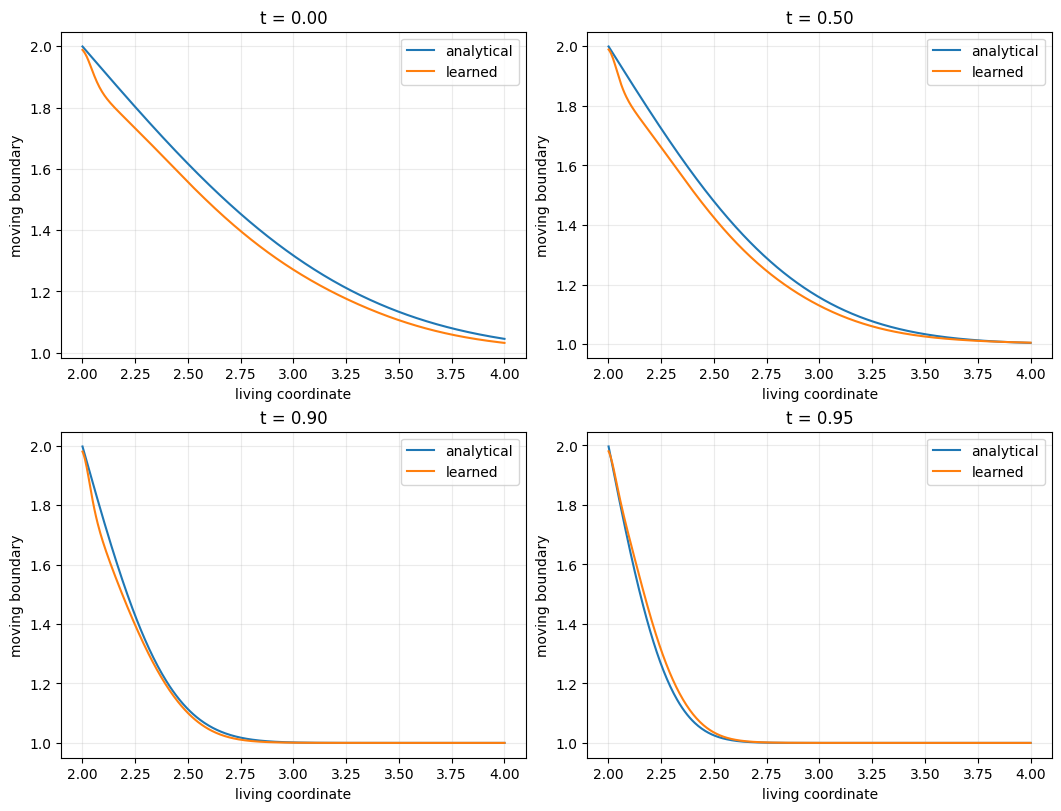

In [10]:
@torch.no_grad()
def exact_singleton_value(
    t: float | Tensor,
    x: Tensor,
) -> Tensor:
    tt = torch.as_tensor(
        t, device=x.device, dtype=x.dtype
    )
    tt, xx = torch.broadcast_tensors(
        tt, x
    )

    remaining = CFG.T - tt

    terminal = torch.where(
        xx <= 2.0 * CFG.alpha,
        torch.full_like(xx, 2.0),
        torch.full_like(xx, 1.0),
    )

    safe_remaining = remaining.clamp_min(
        torch.finfo(xx.dtype).eps
    )

    argument = torch.minimum(
        (
            2.0 * CFG.alpha - xx
        )
        / (
            CFG.sigma
            * torch.sqrt(safe_remaining)
        ),
        torch.zeros_like(xx),
    )

    preterminal = (
        1.0
        + 2.0 * normal_cdf(argument)
    )

    return torch.where(
        remaining <= 1.0e-12,
        terminal,
        preterminal,
    )


@torch.no_grad()
def singleton_validation_table() -> pd.DataFrame:
    x = torch.linspace(
        2.001,
        CFG.x_max,
        800,
        device=DEVICE,
        dtype=DTYPE,
    )

    rows = []
    for t in CFG.validation_times:
        learned = learned_singleton_value(
            t, x
        )
        exact = exact_singleton_value(
            t, x
        )
        error = learned - exact

        rows.append({
            "time": t,
            "singleton_MAE": float(
                error.abs().mean().cpu()
            ),
            "singleton_RMSE": float(
                torch.sqrt(
                    error.square().mean()
                ).cpu()
            ),
            "singleton_max_error": float(
                error.abs().max().cpu()
            ),
            "boundary_MAE": float(
                (CFG.alpha * error).abs().mean().cpu()
            ),
            "boundary_RMSE": float(
                torch.sqrt(
                    (CFG.alpha * error).square().mean()
                ).cpu()
            ),
            "boundary_max_error": float(
                (CFG.alpha * error).abs().max().cpu()
            ),
        })

    return pd.DataFrame(rows)


singleton_metrics = singleton_validation_table()
singleton_metrics.to_csv(
    RESULTS_DIR / "N2_singleton_metrics.csv",
    index=False,
)
display(singleton_metrics.round(6))


x = torch.linspace(
    2.001,
    CFG.x_max,
    500,
    device=DEVICE,
    dtype=DTYPE,
)

fig, axes = plt.subplots(
    2, 2,
    figsize=(10.5, 8.0),
    constrained_layout=True,
)

for ax, t in zip(
    axes.flat,
    CFG.validation_times,
):
    exact = (
        CFG.alpha
        * exact_singleton_value(t, x)
    )
    learned = learned_boundary_value(
        t, x
    )

    ax.plot(
        tensor_to_numpy(x),
        tensor_to_numpy(exact),
        label="analytical",
    )
    ax.plot(
        tensor_to_numpy(x),
        tensor_to_numpy(learned),
        label="learned",
    )

    ax.set_xlabel("living coordinate")
    ax.set_ylabel("moving boundary")
    ax.set_title(f"t = {t:.2f}")
    ax.grid(alpha=0.25)
    ax.legend()

save_figure(
    fig,
    RESULTS_DIR / "singleton_moving_boundary.pdf",
)

In [11]:
def n2_stop_target(
    batch: BrownianBatch,
) -> tuple[Tensor, Tensor, Tensor]:
    smaller = batch.paths.min(dim=2).values
    larger = batch.paths.max(dim=2).values

    threshold = learned_boundary_value(
        batch.times,
        larger,
    )

    lower_value = learned_singleton_value(
        batch.times,
        larger,
    )

    outside_domain = (
        smaller <= threshold
    )

    stop_index, hit = first_true_index(
        outside_domain
    )

    stopped_lower = lower_value.gather(
        1,
        stop_index[:, None],
    )[:, 0]

    stop_target = torch.where(
        hit,
        stopped_lower,
        torch.zeros_like(stopped_lower),
    )

    return (
        stop_index,
        stop_target,
        hit,
    )


def learned_terminal_domain(
    points: Tensor,
) -> Tensor:
    smaller = points.min(dim=1).values
    larger = points.max(dim=1).values

    threshold = learned_boundary_value(
        torch.ones_like(larger),
        larger,
    )

    return smaller > threshold


def sample_n2_training_data(
    *,
    batch_size: int,
    generator: torch.Generator,
    antithetic: bool,
):
    batch = sample_brownian_batch(
        batch_size=batch_size,
        dimension=2,
        x_min=CFG.x_min,
        x_max=CFG.x_max,
        cfg=CFG,
        generator=generator,
        antithetic=antithetic,
    )

    boundary_time = stratified_restart_times(
        batch_size,
        CFG,
        generator,
    )

    survivor = uniform(
        (batch_size,),
        2.001,
        CFG.x_max,
        generator,
    )

    terminal_points = uniform(
        (batch_size, 2),
        CFG.x_min,
        CFG.x_max,
        generator,
    )

    return (
        batch,
        boundary_time,
        survivor,
        terminal_points,
    )


def n2_loss(
    *,
    model: SymmetricTwoParticleFBSDE,
    data,
) -> tuple[Tensor, dict[str, Tensor]]:
    (
        batch,
        boundary_time,
        survivor,
        terminal_points,
    ) = data

    with torch.no_grad():
        stop_index, stop_target, hit = (
            n2_stop_target(batch)
        )

    stopped_y = forward_two_particle(
        model,
        batch,
        stop_index,
    )

    stopped_loss = (
        stopped_y
        - stop_target
    ).square().mean()

    alive_state_loss, exit_step_loss = (
        n2_configuration_losses(
            model,
            batch,
            stop_index,
            stop_target,
            hit,
        )
    )

    with torch.no_grad():
        threshold = learned_boundary_value(
            boundary_time,
            survivor,
        )

        lower_value = learned_singleton_value(
            boundary_time,
            survivor,
        )

    boundary_point_one = torch.stack(
        (
            threshold,
            survivor,
        ),
        dim=1,
    )

    boundary_point_two = torch.stack(
        (
            survivor,
            threshold,
        ),
        dim=1,
    )

    boundary_condition_loss = 0.5 * (
        (
            model.value(
                boundary_time,
                boundary_point_one,
            )
            - lower_value
        ).square().mean()
        +
        (
            model.value(
                boundary_time,
                boundary_point_two,
            )
            - lower_value
        ).square().mean()
    )

    with torch.no_grad():
        terminal_in_domain = (
            learned_terminal_domain(
                terminal_points
            )
        )

    terminal_prediction = model.value(
        CFG.T,
        terminal_points,
    )

    terminal_loss = masked_mean(
        terminal_prediction.square(),
        terminal_in_domain,
    )

    total = (
        stopped_loss
        + CFG.alive_state_weight
        * alive_state_loss
        + CFG.exit_step_weight
        * exit_step_loss
        + boundary_condition_loss
        + terminal_loss
    )

    return total, {
        "stopped": stopped_loss,
        "alive": alive_state_loss,
        "exit": exit_step_loss,
        "boundary": boundary_condition_loss,
        "terminal": terminal_loss,
    }


seed_everything(SEED + 600)


n2_model = SymmetricTwoParticleFBSDE(
    CFG
).to(DEVICE)


n2_train_generator = make_generator(
    SEED + 601
)

n2_validation_generator = make_generator(
    SEED + 602
)


n2_validation_data = sample_n2_training_data(
    batch_size=CFG.validation_size,
    generator=n2_validation_generator,
    antithetic=False,
)


def n2_train_objective(model):
    data = sample_n2_training_data(
        batch_size=CFG.batch_size,
        generator=n2_train_generator,
        antithetic=True,
    )

    return n2_loss(
        model=model,
        data=data,
    )


def n2_validation_objective(model):
    return n2_loss(
        model=model,
        data=n2_validation_data,
    )


n2_training = train(
    model=n2_model,
    name="n2",
    train_objective=n2_train_objective,
    validation_objective=n2_validation_objective,
    iterations=CFG.iterations_n2,
    cfg=CFG,
)

n2                       iter= 1000 val=2.7976e-01 stopped=1.309e-01 alive=1.720e-03 exit=1.782e-01 boundary=8.998e-02 terminal=4.088e-02
n2                       iter= 2000 val=2.4219e-01 stopped=1.159e-01 alive=1.857e-03 exit=1.496e-01 boundary=6.261e-02 terminal=4.850e-02
n2                       iter= 3000 val=1.5959e-01 stopped=7.324e-02 alive=1.354e-03 exit=1.225e-01 boundary=3.928e-02 terminal=3.470e-02
n2                       iter= 4000 val=9.1645e-02 stopped=4.264e-02 alive=1.145e-03 exit=7.839e-02 boundary=2.707e-02 terminal=1.398e-02
n2                       iter= 5000 val=6.8658e-02 stopped=3.455e-02 alive=1.140e-03 exit=5.781e-02 boundary=1.940e-02 terminal=8.807e-03
n2                       iter= 6000 val=5.7975e-02 stopped=3.073e-02 alive=1.344e-03 exit=4.473e-02 boundary=1.196e-02 terminal=1.068e-02
n2                       iter= 7000 val=4.9833e-02 stopped=2.810e-02 alive=1.413e-03 exit=3.995e-02 boundary=1.008e-02 terminal=7.519e-03
n2                       iter= 800

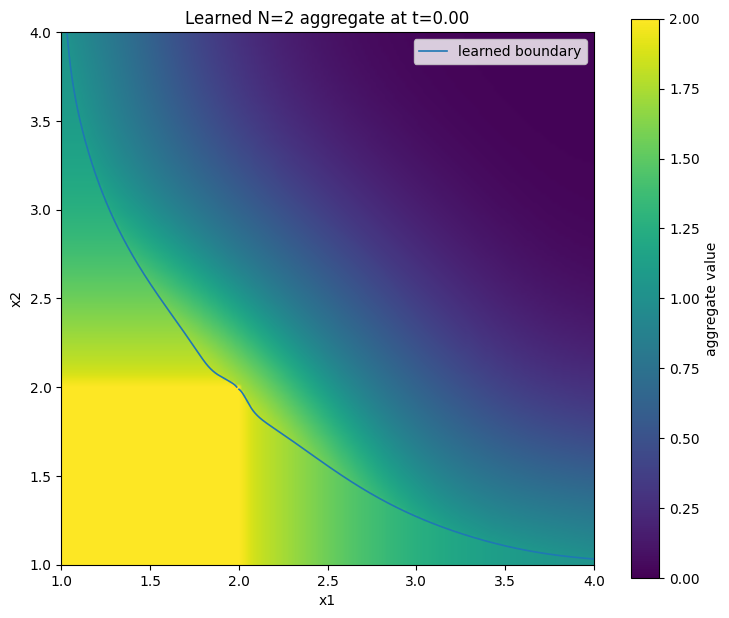

In [12]:
@torch.no_grad()
def completed_n2_value(
    t: float,
    points: Tensor,
) -> Tensor:
    tt = torch.full(
        (points.shape[0],),
        float(t),
        device=points.device,
        dtype=points.dtype,
    )

    raw = n2_model.value(
        tt,
        points,
    )

    smaller = points.min(dim=1).values
    larger = points.max(dim=1).values

    threshold = learned_boundary_value(
        tt,
        larger,
    )
    lower_value = learned_singleton_value(
        tt,
        larger,
    )

    in_domain = smaller > threshold

    if abs(t - CFG.T) <= 1.0e-12:
        raw = torch.zeros_like(raw)

    return torch.where(
        in_domain,
        raw,
        lower_value,
    )


@torch.no_grad()
def plot_n2_field(t: float) -> None:
    axis = torch.linspace(
        CFG.x_min,
        CFG.x_max,
        CFG.plot_grid,
        device=DEVICE,
        dtype=DTYPE,
    )
    x1, x2 = torch.meshgrid(
        axis,
        axis,
        indexing="ij",
    )
    points = torch.stack(
        (x1.reshape(-1), x2.reshape(-1)),
        dim=1,
    )

    field = completed_n2_value(
        t,
        points,
    ).reshape(
        CFG.plot_grid,
        CFG.plot_grid,
    )

    survivor = torch.linspace(
        2.001,
        CFG.x_max,
        600,
        device=DEVICE,
        dtype=DTYPE,
    )
    boundary = learned_boundary_value(
        t,
        survivor,
    )

    fig, ax = plt.subplots(
        figsize=(7.2, 6.2),
        constrained_layout=True,
    )
    image = ax.imshow(
        tensor_to_numpy(field).T,
        origin="lower",
        extent=[
            CFG.x_min,
            CFG.x_max,
            CFG.x_min,
            CFG.x_max,
        ],
        aspect="equal",
        interpolation="bilinear",
        vmin=0.0,
        vmax=2.0,
    )

    boundary_line, = ax.plot(
        tensor_to_numpy(boundary),
        tensor_to_numpy(survivor),
        linewidth=1.2,
        label="learned boundary",
    )
    ax.plot(
        tensor_to_numpy(survivor),
        tensor_to_numpy(boundary),
        linewidth=1.2,
        color=boundary_line.get_color(),
    )

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(
        f"Learned N=2 aggregate at t={t:.2f}"
    )
    ax.legend()
    fig.colorbar(
        image,
        ax=ax,
        label="aggregate value",
    )

    save_figure(
        fig,
        RESULTS_DIR / f"n2_field_t_{t:.2f}.pdf",
    )


plot_n2_field(0.0)

In [13]:
@torch.no_grad()
def exact_boundary_value(
    t: float | Tensor,
    survivor: Tensor,
) -> Tensor:
    return (
        CFG.alpha
        * exact_singleton_value(
            t,
            survivor,
        )
    )


@torch.no_grad()
def exact_n2_in_domain(
    t: float,
    points: Tensor,
) -> Tensor:
    smaller = points.min(dim=1).values
    larger = points.max(dim=1).values

    return (
        smaller
        > exact_boundary_value(
            t,
            larger,
        )
    )


@torch.no_grad()
def reference_payoff_chunk(
    *,
    start_time: float,
    points: Tensor,
    increments: Tensor,
) -> Tensor:
    n_points = points.shape[0]
    n_paths = increments.shape[0]
    n_steps = increments.shape[1]

    dt = (
        CFG.T - start_time
    ) / n_steps

    x = points[:, None, :].expand(
        n_points,
        n_paths,
        2,
    ).clone()

    alive = torch.ones(
        n_points,
        n_paths,
        device=DEVICE,
        dtype=torch.bool,
    )

    payoff = torch.zeros(
        n_points,
        n_paths,
        device=DEVICE,
        dtype=DTYPE,
    )

    for k in range(n_steps + 1):
        current_time = (
            start_time + k * dt
        )

        smaller = x.min(dim=2).values
        larger = x.max(dim=2).values

        threshold = exact_boundary_value(
            current_time,
            larger,
        )

        first_exit = (
            alive
            & (smaller <= threshold)
        )

        if bool(first_exit.any()):
            payoff[first_exit] = (
                exact_singleton_value(
                    current_time,
                    larger[first_exit],
                )
            )
            alive[first_exit] = False

        if k < n_steps:
            x = (
                x
                + CFG.sigma
                * increments[:, k][None, :, :]
            )

    return payoff


@torch.no_grad()
def independent_reference_t0():
    axis = torch.linspace(
        CFG.x_min,
        CFG.x_max,
        CFG.reference_grid,
        device=DEVICE,
        dtype=DTYPE,
    )

    x1, x2 = torch.meshgrid(
        axis,
        axis,
        indexing="ij",
    )

    points = torch.stack(
        (x1.reshape(-1), x2.reshape(-1)),
        dim=1,
    )

    in_domain = exact_n2_in_domain(
        0.0,
        points,
    )

    reference = exact_singleton_value(
        0.0,
        points.max(dim=1).values,
    )

    inside_points = points[in_domain]

    if CFG.reference_paths % 2 != 0:
        raise ValueError(
            "reference_paths must be even"
        )

    half = CFG.reference_paths // 2
    generator = make_generator(
        SEED + 10_000
    )

    half_normals = torch.randn(
        half,
        CFG.reference_steps,
        2,
        generator=generator,
        device=DEVICE,
        dtype=DTYPE,
    )

    normals = torch.cat(
        (half_normals, -half_normals),
        dim=0,
    )

    dt = CFG.T / CFG.reference_steps
    dW = math.sqrt(dt) * normals

    estimates = []
    standard_errors = []

    for start in range(
        0,
        len(inside_points),
        CFG.reference_point_batch,
    ):
        chunk = inside_points[
            start:
            start + CFG.reference_point_batch
        ]

        samples = reference_payoff_chunk(
            start_time=0.0,
            points=chunk,
            increments=dW,
        )

        pair_mean = 0.5 * (
            samples[:, :half]
            + samples[:, half:]
        )

        estimates.append(
            pair_mean.mean(dim=1)
        )
        standard_errors.append(
            pair_mean.std(
                dim=1,
                unbiased=True,
            ) / math.sqrt(half)
        )

    reference[in_domain] = torch.cat(
        estimates
    )
    reference_se = torch.zeros_like(reference)
    reference_se[in_domain] = torch.cat(
        standard_errors
    )

    learned = completed_n2_value(
        0.0,
        points,
    )

    error = learned[in_domain] - reference[in_domain]

    metrics = {
        "field_MAE": float(
            error.abs().mean().cpu()
        ),
        "field_RMSE": float(
            torch.sqrt(
                error.square().mean()
            ).cpu()
        ),
        "field_max_error": float(
            error.abs().max().cpu()
        ),
        "reference_mean_MC_SE": float(
            reference_se[in_domain].mean().cpu()
        ),
        "reference_max_MC_SE": float(
            reference_se[in_domain].max().cpu()
        ),
    }

    return (
        axis,
        points,
        in_domain,
        reference,
        learned,
        reference_se,
        metrics,
    )


(
    reference_axis,
    reference_points,
    reference_in_domain,
    reference_field,
    learned_field,
    reference_standard_error,
    n2_reference_metrics,
) = independent_reference_t0()

n2_reference_metrics_table = pd.DataFrame(
    [n2_reference_metrics]
)

n2_reference_metrics_table.to_csv(
    RESULTS_DIR / "N2_independent_field_metrics.csv",
    index=False,
)

display(
    n2_reference_metrics_table.round(6)
)


,field_MAE,field_RMSE,field_max_error,reference_mean_MC_SE,reference_max_MC_SE
0,0.077526,0.086633,0.183106,0.009531,0.013395


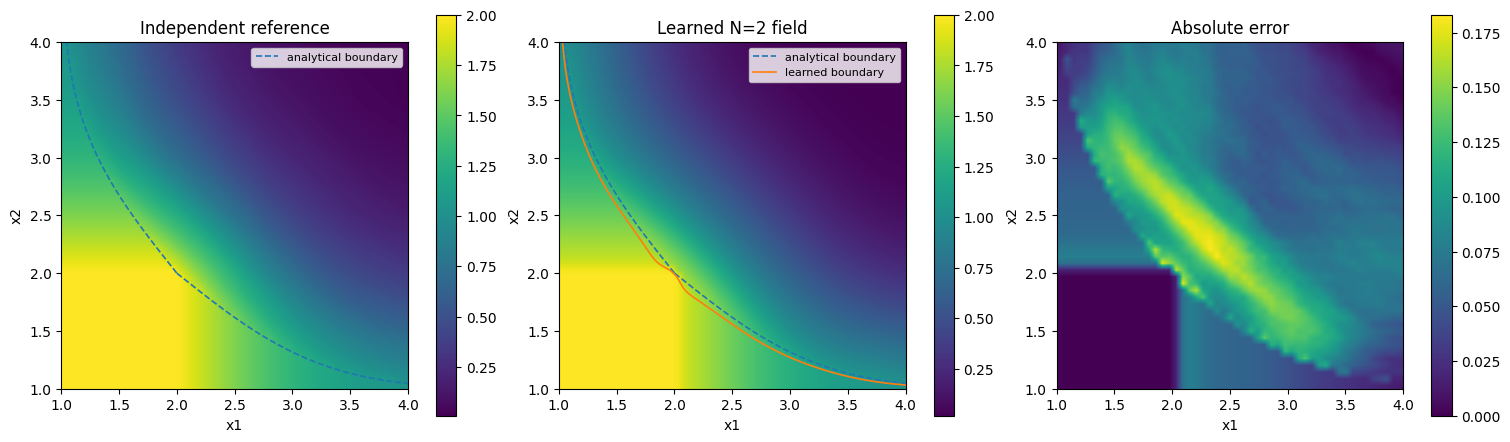

In [14]:
reference_array = tensor_to_numpy(
    reference_field
).reshape(
    CFG.reference_grid,
    CFG.reference_grid,
)

learned_array = tensor_to_numpy(
    learned_field
).reshape(
    CFG.reference_grid,
    CFG.reference_grid,
)

error_array = np.abs(
    learned_array - reference_array
)

axis_np = tensor_to_numpy(
    reference_axis
)

survivor = torch.linspace(
    2.001,
    CFG.x_max,
    600,
    device=DEVICE,
    dtype=DTYPE,
)

exact_boundary = exact_boundary_value(
    0.0,
    survivor,
)
learned_boundary = learned_boundary_value(
    0.0,
    survivor,
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15.0, 4.8),
    constrained_layout=True,
)

for ax, values, title in (
    (
        axes[0],
        reference_array,
        "Independent reference",
    ),
    (
        axes[1],
        learned_array,
        "Learned N=2 field",
    ),
    (
        axes[2],
        error_array,
        "Absolute error",
    ),
):
    image = ax.imshow(
        values.T,
        origin="lower",
        extent=[
            axis_np[0],
            axis_np[-1],
            axis_np[0],
            axis_np[-1],
        ],
        aspect="equal",
        interpolation="bilinear",
    )

    if title != "Absolute error":
        exact_line, = ax.plot(
            tensor_to_numpy(
                exact_boundary
            ),
            tensor_to_numpy(
                survivor
            ),
            linestyle="--",
            linewidth=1.2,
            label="analytical boundary",
        )
        ax.plot(
            tensor_to_numpy(
                survivor
            ),
            tensor_to_numpy(
                exact_boundary
            ),
            linestyle="--",
            linewidth=1.2,
            color=exact_line.get_color(),
        )

        if title == "Learned N=2 field":
            learned_line, = ax.plot(
                tensor_to_numpy(
                    learned_boundary
                ),
                tensor_to_numpy(
                    survivor
                ),
                linewidth=1.2,
                label="learned boundary",
            )
            ax.plot(
                tensor_to_numpy(
                    survivor
                ),
                tensor_to_numpy(
                    learned_boundary
                ),
                linewidth=1.2,
                color=learned_line.get_color(),
            )

        ax.legend(fontsize=8)

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(title)
    fig.colorbar(
        image,
        ax=ax,
        shrink=0.85,
    )

save_figure(
    fig,
    RESULTS_DIR / "n2_reference_learned_error.pdf",
)

## Higher-dimensional cascade

In [15]:
def symmetric_statistics(
    x: Tensor,
    number: int,
) -> Tensor:
    mean = x.mean(
        dim=1,
        keepdim=True,
    )

    if number == 1:
        return mean

    centred = x - mean
    features = [mean]

    for power in range(
        2,
        number + 1,
    ):
        features.append(
            centred.pow(power).mean(
                dim=1,
                keepdim=True,
            )
        )

    return torch.cat(
        features,
        dim=1,
    )


class GeneralSingletonFBSDE(nn.Module):
    def __init__(
        self,
        total_particles: int,
    ) -> None:
        super().__init__()

        self.total_particles = total_particles
        threshold = (
            CFG.alpha * total_particles
        )
        x_high = max(
            CFG.x_max,
            threshold + 2.0,
        )

        x_center = 0.5 * (
            threshold + x_high
        )
        x_scale = 0.5 * (
            x_high - threshold
        )

        self.value_net = NormalisedMLP(
            2,
            1,
            CFG.width,
            CFG.depth,
            center=(0.5, x_center),
            scale=(0.5, x_scale),
        )
        self.z_net = NormalisedMLP(
            2,
            1,
            CFG.width,
            CFG.depth,
            center=(0.5, x_center),
            scale=(0.5, x_scale),
        )

    def value(
        self,
        t: float | Tensor,
        x: Tensor,
    ) -> Tensor:
        x = x.reshape(-1)

        tc = time_column(
            t,
            x.shape[0],
            device=x.device,
            dtype=x.dtype,
        )

        raw = self.value_net(
            torch.cat(
                (tc, x[:, None]),
                dim=1,
            )
        )[:, 0]

        return (
            float(
                self.total_particles - 1
            )
            + torch.sigmoid(raw)
        )

    def z(
        self,
        t: float | Tensor,
        x: Tensor,
    ) -> Tensor:
        x = x.reshape(-1)

        tc = time_column(
            t,
            x.shape[0],
            device=x.device,
            dtype=x.dtype,
        )

        return self.z_net(
            torch.cat(
                (tc, x[:, None]),
                dim=1,
            )
        )[:, 0]



class GeneralTwoParticleFBSDE(nn.Module):
    """
    Same smooth N=2 architecture as the successful model, with
    total-population-specific input normalisation for N=3 and N=4.
    """

    def __init__(
        self,
        total_particles: int,
    ) -> None:
        super().__init__()

        x_high = max(
            CFG.x_max,
            CFG.alpha
            * total_particles
            + 2.0,
        )

        x_center = 0.5 * (
            CFG.x_min + x_high
        )
        x_scale = 0.5 * (
            x_high - CFG.x_min
        )

        self.value_net = NormalisedMLP(
            3,
            1,
            CFG.width,
            CFG.depth,
            center=(
                0.5,
                x_center,
                0.5 * x_scale**2,
            ),
            scale=(
                0.5,
                x_scale,
                0.5 * x_scale**2,
            ),
        )

        self.z_component_net = NormalisedMLP(
            3,
            1,
            CFG.width,
            CFG.depth,
            center=(
                0.5,
                x_center,
                x_center,
            ),
            scale=(
                0.5,
                x_scale,
                x_scale,
            ),
        )

    def value(
        self,
        t: float | Tensor,
        x: Tensor,
    ) -> Tensor:
        tc = time_column(
            t,
            x.shape[0],
            device=x.device,
            dtype=x.dtype,
        )

        mean = x.mean(
            dim=1,
            keepdim=True,
        )

        variance = 0.25 * (
            x[:, 0:1]
            - x[:, 1:2]
        ).square()

        return self.value_net(
            torch.cat(
                (
                    tc,
                    mean,
                    variance,
                ),
                dim=1,
            )
        )[:, 0]

    def z(
        self,
        t: float | Tensor,
        x: Tensor,
    ) -> Tensor:
        tc = time_column(
            t,
            x.shape[0],
            device=x.device,
            dtype=x.dtype,
        )

        z1 = self.z_component_net(
            torch.cat(
                (
                    tc,
                    x[:, 0:1],
                    x[:, 1:2],
                ),
                dim=1,
            )
        )

        z2 = self.z_component_net(
            torch.cat(
                (
                    tc,
                    x[:, 1:2],
                    x[:, 0:1],
                ),
                dim=1,
            )
        )

        return torch.cat(
            (z1, z2),
            dim=1,
        )


class HigherSymmetricFBSDE(nn.Module):
    def __init__(
        self,
        total_particles: int,
        alive_particles: int,
    ) -> None:
        super().__init__()

        if alive_particles < 3:
            raise ValueError(
                "HigherSymmetricFBSDE is for m>=3"
            )

        self.total_particles = total_particles
        self.alive_particles = alive_particles

        x_high = max(
            CFG.x_max,
            CFG.alpha
            * total_particles
            + 2.0,
        )

        x_center = 0.5 * (
            CFG.x_min + x_high
        )
        x_scale = 0.5 * (
            x_high - CFG.x_min
        )

        value_center = [
            0.5,
            x_center,
        ]
        value_scale = [
            0.5,
            x_scale,
        ]

        for power in range(
            2,
            alive_particles + 1,
        ):
            value_center.append(0.0)
            value_scale.append(
                max(
                    1.0,
                    x_scale ** power,
                )
            )

        self.value_net = NormalisedMLP(
            1 + alive_particles,
            1,
            CFG.width,
            CFG.depth,
            center=tuple(value_center),
            scale=tuple(value_scale),
        )

        remaining = alive_particles - 1

        z_center = [
            0.5,
            x_center,
            x_center,
        ]
        z_scale = [
            0.5,
            x_scale,
            x_scale,
        ]

        for power in range(
            2,
            remaining + 1,
        ):
            z_center.append(0.0)
            z_scale.append(
                max(
                    1.0,
                    x_scale ** power,
                )
            )

        self.z_component_net = NormalisedMLP(
            len(z_center),
            1,
            CFG.width,
            CFG.depth,
            center=tuple(z_center),
            scale=tuple(z_scale),
        )

    def value(
        self,
        t: float | Tensor,
        x: Tensor,
    ) -> Tensor:
        tc = time_column(
            t,
            x.shape[0],
            device=x.device,
            dtype=x.dtype,
        )

        statistics = symmetric_statistics(
            x,
            self.alive_particles,
        )

        return self.value_net(
            torch.cat(
                (tc, statistics),
                dim=1,
            )
        )[:, 0]

    def z(
        self,
        t: float | Tensor,
        x: Tensor,
    ) -> Tensor:
        tc = time_column(
            t,
            x.shape[0],
            device=x.device,
            dtype=x.dtype,
        )

        components = []

        for j in range(
            self.alive_particles
        ):
            own = x[:, j:j + 1]

            remaining = torch.cat(
                (
                    x[:, :j],
                    x[:, j + 1:],
                ),
                dim=1,
            )

            remaining_statistics = (
                symmetric_statistics(
                    remaining,
                    self.alive_particles - 1,
                )
            )

            features = torch.cat(
                (
                    tc,
                    own,
                    remaining_statistics,
                ),
                dim=1,
            )

            components.append(
                self.z_component_net(
                    features
                )[:, 0]
            )

        return torch.stack(
            components,
            dim=1,
        )

In [16]:
@torch.no_grad()
def completed_value(
    total_particles: int,
    alive_particles: int,
    t: float | Tensor,
    x: Tensor,
    models: dict[int, nn.Module],
) -> Tensor:
    if alive_particles == 0:
        return torch.full(
            (x.shape[0],),
            float(total_particles),
            device=x.device,
            dtype=x.dtype,
        )

    if alive_particles == 1:
        raw = models[1].value(
            t,
            x[:, 0],
        )

        threshold = (
            CFG.alpha
            * total_particles
        )

        return torch.where(
            x[:, 0] <= threshold,
            torch.full_like(
                raw,
                float(total_particles),
            ),
            raw,
        )

    raw = models[
        alive_particles
    ].value(
        t,
        x,
    )

    lower_values = []
    margins = []

    for i in range(
        alive_particles
    ):
        reduced = torch.cat(
            (
                x[:, :i],
                x[:, i + 1:],
            ),
            dim=1,
        )

        lower = completed_value(
            total_particles,
            alive_particles - 1,
            t,
            reduced,
            models,
        )

        lower_values.append(
            lower
        )

        margins.append(
            x[:, i]
            - CFG.alpha * lower
        )

    lower_values = torch.stack(
        lower_values,
        dim=1,
    )

    margins = torch.stack(
        margins,
        dim=1,
    )

    in_domain = (
        margins > 0.0
    ).all(dim=1)

    selected = margins.argmin(
        dim=1
    )

    boundary_value = (
        lower_values.gather(
            1,
            selected[:, None],
        )[:, 0]
    )

    tt = torch.as_tensor(
        t,
        device=x.device,
        dtype=x.dtype,
    )

    if tt.ndim == 0:
        tt = tt.expand(
            x.shape[0]
        )

    terminal_value = torch.full_like(
        raw,
        float(
            total_particles
            - alive_particles
        ),
    )

    raw = torch.where(
        tt >= CFG.T - 1.0e-10,
        terminal_value,
        raw,
    )

    return torch.where(
        in_domain,
        raw,
        boundary_value,
    )


@torch.no_grad()
def level_stop_target(
    total_particles: int,
    alive_particles: int,
    batch: BrownianBatch,
    lower_models: dict[int, nn.Module],
):
    batch_size, time_count, _ = (
        batch.paths.shape
    )

    lower_values = []
    margins = []

    flat_time = batch.times.reshape(
        -1
    )

    for i in range(
        alive_particles
    ):
        reduced = torch.cat(
            (
                batch.paths[:, :, :i],
                batch.paths[:, :, i + 1:],
            ),
            dim=2,
        ).reshape(
            -1,
            alive_particles - 1,
        )

        lower = completed_value(
            total_particles,
            alive_particles - 1,
            flat_time,
            reduced,
            lower_models,
        ).reshape(
            batch_size,
            time_count,
        )

        lower_values.append(
            lower
        )

        margins.append(
            batch.paths[:, :, i]
            - CFG.alpha * lower
        )

    lower_values = torch.stack(
        lower_values,
        dim=2,
    )

    margins = torch.stack(
        margins,
        dim=2,
    )

    outside_domain = (
        margins <= 0.0
    ).any(dim=2)

    stop_index, hit = (
        first_true_index(
            outside_domain
        )
    )

    row = torch.arange(
        batch_size,
        device=DEVICE,
    )

    stopped_margins = margins[
        row,
        stop_index,
    ]

    stopped_lower = lower_values[
        row,
        stop_index,
    ]

    selected = stopped_margins.argmin(
        dim=1
    )

    exit_value = (
        stopped_lower.gather(
            1,
            selected[:, None],
        )[:, 0]
    )

    terminal_value = torch.full_like(
        exit_value,
        float(
            total_particles
            - alive_particles
        ),
    )

    target = torch.where(
        hit,
        exit_value,
        terminal_value,
    )

    return stop_index, target, hit

In [17]:
def forward_generic_level(
    model: nn.Module,
    batch: BrownianBatch,
    stop_index: Tensor,
    alive_particles: int,
) -> Tensor:
    if alive_particles == 1:
        y = model.value(
            batch.start_time,
            batch.x0[:, 0],
        )
    else:
        y = model.value(
            batch.start_time,
            batch.x0,
        )

    for k in range(
        batch.dW.shape[1]
    ):
        before_exit = (
            stop_index > k
        ).to(DTYPE)

        if alive_particles == 1:
            z = model.z(
                batch.times[:, k],
                batch.paths[:, k, 0],
            )
            increment = (
                z
                * batch.dW[:, k, 0]
            )
        else:
            z = model.z(
                batch.times[:, k],
                batch.paths[:, k],
            )
            increment = (
                z
                * batch.dW[:, k]
            ).sum(dim=1)

        y = y + (
            before_exit
            * increment
        )

    return y


def generic_configuration_losses(
    model: nn.Module,
    batch: BrownianBatch,
    stop_index: Tensor,
    stop_target: Tensor,
    hit: Tensor,
    alive_particles: int,
) -> tuple[Tensor, Tensor]:
    def value_function(t, x):
        if alive_particles == 1:
            return model.value(
                t,
                x[:, 0],
            )
        return model.value(t, x)

    def z_function(t, x):
        if alive_particles == 1:
            return model.z(
                t,
                x[:, 0],
            )
        return model.z(t, x)

    return local_configuration_losses(
        value_function=value_function,
        z_function=z_function,
        batch=batch,
        stop_index=stop_index,
        stop_target=stop_target,
        hit=hit,
    )


@torch.no_grad()
def lower_domain_mask(
    total_particles: int,
    alive_particles: int,
    t: Tensor,
    x: Tensor,
    models: dict[int, nn.Module],
) -> Tensor:
    if alive_particles == 1:
        return (
            x[:, 0]
            > CFG.alpha
            * total_particles
        )

    margins = []

    for i in range(
        alive_particles
    ):
        reduced = torch.cat(
            (
                x[:, :i],
                x[:, i + 1:],
            ),
            dim=1,
        )

        lower = completed_value(
            total_particles,
            alive_particles - 1,
            t,
            reduced,
            models,
        )

        margins.append(
            x[:, i]
            - CFG.alpha * lower
        )

    return (
        torch.stack(
            margins,
            dim=1,
        )
        > 0.0
    ).all(dim=1)


@torch.no_grad()
def sample_generic_boundary_data(
    total_particles: int,
    alive_particles: int,
    models: dict[int, nn.Module],
    generator: torch.Generator,
    size: int,
):
    t = stratified_restart_times(
        size,
        CFG,
        generator,
    )

    x_high = max(
        CFG.x_max,
        CFG.alpha
        * total_particles
        + 2.0,
    )

    accepted_t = []
    accepted_survivor = []
    needed = size

    for _ in range(200):
        if needed <= 0:
            break

        proposal = max(
            2 * needed,
            64,
        )

        proposal_t = (
            stratified_restart_times(
                proposal,
                CFG,
                generator,
            )
        )

        survivor = uniform(
            (
                proposal,
                alive_particles - 1,
            ),
            CFG.x_min,
            x_high,
            generator,
        )

        valid = lower_domain_mask(
            total_particles,
            alive_particles - 1,
            proposal_t,
            survivor,
            models,
        )

        if bool(valid.any()):
            rows = valid.nonzero(
                as_tuple=False
            ).flatten()[:needed]

            accepted_t.append(
                proposal_t[rows]
            )
            accepted_survivor.append(
                survivor[rows]
            )
            needed -= len(rows)

    if needed > 0:
        raise RuntimeError(
            "Could not sample enough lower-level states in the domain"
        )

    t = torch.cat(
        accepted_t,
        dim=0,
    )[:size]

    survivor = torch.cat(
        accepted_survivor,
        dim=0,
    )[:size]

    lower = completed_value(
        total_particles,
        alive_particles - 1,
        t,
        survivor,
        models,
    )

    boundary_coordinate = (
        CFG.alpha * lower
    )[:, None]

    point = torch.cat(
        (
            boundary_coordinate,
            survivor,
        ),
        dim=1,
    )

    rows = []

    for r in range(size):
        permutation = torch.randperm(
            alive_particles,
            generator=generator,
            device=DEVICE,
        )
        rows.append(
            point[r, permutation]
        )

    return (
        t,
        torch.stack(
            rows,
            dim=0,
        ),
        lower,
    )


@torch.no_grad()
def generic_terminal_mask(
    total_particles: int,
    alive_particles: int,
    points: Tensor,
    lower_models: dict[int, nn.Module],
) -> Tensor:
    batch_size = points.shape[0]

    time = torch.full(
        (batch_size, 1),
        CFG.T,
        device=DEVICE,
        dtype=DTYPE,
    )

    paths = points[:, None, :]

    margins = []

    for i in range(
        alive_particles
    ):
        reduced = torch.cat(
            (
                paths[:, :, :i],
                paths[:, :, i + 1:],
            ),
            dim=2,
        ).reshape(
            batch_size,
            alive_particles - 1,
        )

        lower = completed_value(
            total_particles,
            alive_particles - 1,
            time[:, 0],
            reduced,
            lower_models,
        )

        margins.append(
            points[:, i]
            - CFG.alpha * lower
        )

    margins = torch.stack(
        margins,
        dim=1,
    )

    return (
        margins > 0.0
    ).all(dim=1)


def aggregate_range_loss(
    prediction: Tensor,
    lower: float,
    upper: float,
) -> Tensor:
    return (
        torch.relu(
            lower - prediction
        ).square().mean()
        +
        torch.relu(
            prediction - upper
        ).square().mean()
    )


def generic_level_data(
    total_particles: int,
    alive_particles: int,
    models: dict[int, nn.Module],
    *,
    batch_size: int,
    generator: torch.Generator,
    antithetic: bool,
):
    x_high = max(
        CFG.x_max,
        CFG.alpha
        * total_particles
        + 2.0,
    )

    batch = sample_brownian_batch(
        batch_size=batch_size,
        dimension=alive_particles,
        x_min=CFG.x_min,
        x_max=x_high,
        cfg=CFG,
        generator=generator,
        antithetic=antithetic,
    )

    boundary_data = (
        sample_generic_boundary_data(
            total_particles,
            alive_particles,
            models,
            generator,
            batch_size,
        )
    )

    terminal_points = uniform(
        (
            batch_size,
            alive_particles,
        ),
        CFG.x_min,
        x_high,
        generator,
    )

    range_time = (
        stratified_restart_times(
            batch_size,
            CFG,
            generator,
        )
    )

    range_points = uniform(
        (
            batch_size,
            alive_particles,
        ),
        CFG.x_min,
        x_high,
        generator,
    )

    return (
        batch,
        boundary_data,
        terminal_points,
        range_time,
        range_points,
    )


def generic_level_loss(
    total_particles: int,
    alive_particles: int,
    model: nn.Module,
    lower_models: dict[int, nn.Module],
    data,
):
    (
        batch,
        boundary_data,
        terminal_points,
        range_time,
        range_points,
    ) = data

    with torch.no_grad():
        (
            stop_index,
            stop_target,
            hit,
        ) = level_stop_target(
            total_particles,
            alive_particles,
            batch,
            lower_models,
        )

    stopped_y = forward_generic_level(
        model,
        batch,
        stop_index,
        alive_particles,
    )

    stopped_loss = (
        stopped_y
        - stop_target
    ).square().mean()

    alive_loss, exit_loss = (
        generic_configuration_losses(
            model,
            batch,
            stop_index,
            stop_target,
            hit,
            alive_particles,
        )
    )

    (
        boundary_time,
        boundary_points,
        boundary_target,
    ) = boundary_data

    boundary_prediction = model.value(
        boundary_time,
        boundary_points,
    )

    boundary_loss = (
        boundary_prediction
        - boundary_target
    ).square().mean()

    with torch.no_grad():
        terminal_mask = (
            generic_terminal_mask(
                total_particles,
                alive_particles,
                terminal_points,
                lower_models,
            )
        )

    terminal_prediction = model.value(
        CFG.T,
        terminal_points,
    )

    terminal_value = float(
        total_particles
        - alive_particles
    )

    terminal_loss = masked_mean(
        (
            terminal_prediction
            - terminal_value
        ).square(),
        terminal_mask,
    )

    range_prediction = model.value(
        range_time,
        range_points,
    )

    range_loss = (
        aggregate_range_loss(
            range_prediction,
            float(
                total_particles
                - alive_particles
            ),
            float(total_particles),
        )
    )

    total = (
        stopped_loss
        + CFG.alive_state_weight
        * alive_loss
        + CFG.exit_step_weight
        * exit_loss
        + boundary_loss
        + terminal_loss
        + CFG.higher_range_weight * range_loss
    )

    return total, {
        "stopped": stopped_loss,
        "alive": alive_loss,
        "exit": exit_loss,
        "boundary": boundary_loss,
        "terminal": terminal_loss,
        "range": range_loss,
    }

In [18]:
def train_general_singleton(
    total_particles: int,
    seed: int,
):
    model = GeneralSingletonFBSDE(
        total_particles
    ).to(DEVICE)

    threshold = (
        CFG.alpha
        * total_particles
    )

    x_high = max(
        CFG.x_max,
        threshold + 2.0,
    )

    train_generator = (
        make_generator(seed + 1)
    )
    validation_generator = (
        make_generator(seed + 2)
    )

    def sample_data(
        batch_size: int,
        generator: torch.Generator,
        antithetic: bool,
    ):
        batch = sample_brownian_batch(
            batch_size=batch_size,
            dimension=1,
            x_min=threshold + 0.001,
            x_max=x_high,
            cfg=CFG,
            generator=generator,
            antithetic=antithetic,
        )

        boundary_time = (
            stratified_restart_times(
                batch_size,
                CFG,
                generator,
            )
        )

        terminal_x = uniform(
            (batch_size,),
            threshold + 0.001,
            x_high,
            generator,
        )

        noninc_time = (
            stratified_restart_times(
                batch_size,
                CFG,
                generator,
            )
        )

        noninc_x = uniform(
            (batch_size,),
            threshold + 0.001,
            x_high,
            generator,
        )

        return (
            batch,
            boundary_time,
            terminal_x,
            noninc_time,
            noninc_x,
        )

    validation_data = sample_data(
        CFG.validation_size,
        validation_generator,
        False,
    )

    def objective(
        current_model,
        data,
    ):
        (
            batch,
            boundary_time,
            terminal_x,
            noninc_time,
            noninc_x,
        ) = data

        outside_domain = (
            batch.paths[:, :, 0]
            <= threshold
        )

        stop_index, hit = (
            first_true_index(
                outside_domain
            )
        )

        target = torch.where(
            hit,
            torch.full_like(
                batch.start_time,
                float(total_particles),
            ),
            torch.full_like(
                batch.start_time,
                float(
                    total_particles - 1
                ),
            ),
        )

        stopped_y = forward_generic_level(
            current_model,
            batch,
            stop_index,
            1,
        )

        stopped_loss = (
            stopped_y - target
        ).square().mean()

        alive_loss, exit_loss = (
            generic_configuration_losses(
                current_model,
                batch,
                stop_index,
                target,
                hit,
                1,
            )
        )

        boundary_prediction = (
            current_model.value(
                boundary_time,
                torch.full_like(
                    boundary_time,
                    threshold,
                ),
            )
        )

        boundary_loss = (
            boundary_prediction
            - float(total_particles)
        ).square().mean()

        terminal_prediction = (
            current_model.value(
                CFG.T,
                terminal_x,
            )
        )

        terminal_loss = (
            terminal_prediction
            - float(
                total_particles - 1
            )
        ).square().mean()

        noninc_x_grad = (
            noninc_x.detach()
            .clone()
            .requires_grad_(True)
        )

        noninc_value = (
            current_model.value(
                noninc_time,
                noninc_x_grad,
            )
        )

        derivative = torch.autograd.grad(
            noninc_value.sum(),
            noninc_x_grad,
            create_graph=True,
        )[0]

        noninc_loss = (
            torch.relu(
                derivative
            ).square().mean()
        )

        total = (
            stopped_loss
            + CFG.alive_state_weight
            * alive_loss
            + CFG.exit_step_weight
            * exit_loss
            + boundary_loss
            + terminal_loss
            + CFG.singleton_nonincreasing_weight
            * noninc_loss
        )

        return total, {
            "stopped": stopped_loss,
            "alive": alive_loss,
            "exit": exit_loss,
            "boundary": boundary_loss,
            "terminal": terminal_loss,
            "noninc": noninc_loss,
        }

    def train_objective(
        current_model,
    ):
        return objective(
            current_model,
            sample_data(
                CFG.batch_size,
                train_generator,
                True,
            ),
        )

    def validation_objective(
        current_model,
    ):
        return objective(
            current_model,
            validation_data,
        )

    training = train(
        model=model,
        name=f"N{total_particles}_level1",
        train_objective=train_objective,
        validation_objective=validation_objective,
        iterations=CFG.iterations_singleton,
        cfg=CFG,
    )

    model.eval()
    for parameter in model.parameters():
        parameter.requires_grad_(False)

    return model, training


def train_general_level(
    total_particles: int,
    alive_particles: int,
    models: dict[int, nn.Module],
    seed: int,
):
    if alive_particles == 2:
        model = GeneralTwoParticleFBSDE(
            total_particles
        ).to(DEVICE)
    else:
        model = HigherSymmetricFBSDE(
            total_particles,
            alive_particles,
        ).to(DEVICE)

    lower_models = {
        key: value
        for key, value
        in models.items()
        if key < alive_particles
    }

    train_generator = (
        make_generator(seed + 1)
    )
    validation_generator = (
        make_generator(seed + 2)
    )

    validation_data = (
        generic_level_data(
            total_particles,
            alive_particles,
            lower_models,
            batch_size=CFG.validation_size,
            generator=validation_generator,
            antithetic=False,
        )
    )

    def train_objective(
        current_model,
    ):
        data = generic_level_data(
            total_particles,
            alive_particles,
            lower_models,
            batch_size=CFG.batch_size,
            generator=train_generator,
            antithetic=True,
        )

        return generic_level_loss(
            total_particles,
            alive_particles,
            current_model,
            lower_models,
            data,
        )

    def validation_objective(
        current_model,
    ):
        return generic_level_loss(
            total_particles,
            alive_particles,
            current_model,
            lower_models,
            validation_data,
        )

    training = train(
        model=model,
        name=(
            f"N{total_particles}_"
            f"level{alive_particles}"
        ),
        train_objective=train_objective,
        validation_objective=validation_objective,
        iterations=CFG.iterations_n2,
        cfg=CFG,
    )

    model.eval()
    for parameter in model.parameters():
        parameter.requires_grad_(False)

    return model, training


def train_general_cascade(
    total_particles: int,
    seed: int,
):
    models = {}
    training = {}

    model, result = (
        train_general_singleton(
            total_particles,
            seed + 100,
        )
    )

    models[1] = model
    training[1] = result

    for alive_particles in range(
        2,
        total_particles + 1,
    ):
        model, result = (
            train_general_level(
                total_particles,
                alive_particles,
                models,
                seed
                + 100
                * alive_particles,
            )
        )

        models[alive_particles] = (
            model
        )
        training[alive_particles] = (
            result
        )

    return models, training

In [19]:
@torch.no_grad()
def exact_general_singleton(
    total_particles: int,
    t: float | Tensor,
    x: Tensor,
) -> Tensor:
    tt = torch.as_tensor(
        t,
        device=x.device,
        dtype=x.dtype,
    )

    tt, xx = torch.broadcast_tensors(
        tt,
        x,
    )

    threshold = (
        CFG.alpha
        * total_particles
    )

    remaining = (
        CFG.T - tt
    )

    terminal = torch.where(
        xx <= threshold,
        torch.full_like(
            xx,
            float(total_particles),
        ),
        torch.full_like(
            xx,
            float(
                total_particles - 1
            ),
        ),
    )

    safe_remaining = (
        remaining.clamp_min(
            torch.finfo(
                xx.dtype
            ).eps
        )
    )

    argument = torch.minimum(
        (
            threshold - xx
        )
        / (
            CFG.sigma
            * torch.sqrt(
                safe_remaining
            )
        ),
        torch.zeros_like(xx),
    )

    preterminal = (
        float(
            total_particles - 1
        )
        + 2.0
        * normal_cdf(argument)
    )

    return torch.where(
        remaining <= 1.0e-12,
        terminal,
        preterminal,
    )


@torch.no_grad()
def general_singleton_metrics(
    total_particles: int,
    models: dict[int, nn.Module],
) -> pd.DataFrame:
    threshold = (
        CFG.alpha
        * total_particles
    )

    x_high = max(
        CFG.x_max,
        threshold + 2.0,
    )

    x = torch.linspace(
        threshold + 0.001,
        x_high,
        800,
        device=DEVICE,
        dtype=DTYPE,
    )

    rows = []

    for t in CFG.validation_times:
        learned = models[1].value(
            t,
            x,
        )

        exact = exact_general_singleton(
            total_particles,
            t,
            x,
        )

        error = learned - exact

        rows.append({
            "time": t,
            "MAE": float(
                error.abs().mean().cpu()
            ),
            "RMSE": float(
                torch.sqrt(
                    error.square().mean()
                ).cpu()
            ),
            "max_error": float(
                error.abs().max().cpu()
            ),
        })

    return pd.DataFrame(rows)

In [20]:
@torch.no_grad()
def projection_metrics(
    higher_total: int,
    higher_models: dict[int, nn.Module],
    lower_total: int,
    lower_models: dict[int, nn.Module],
    far_value: float,
    samples: int = 4096,
) -> pd.DataFrame:
    generator = make_generator(
        SEED
        + 80_000
        + higher_total
    )

    lower_x = uniform(
        (
            samples,
            lower_total,
        ),
        2.5,
        CFG.x_max,
        generator,
    )

    far = torch.full(
        (samples, 1),
        far_value,
        device=DEVICE,
        dtype=DTYPE,
    )

    higher_x = torch.cat(
        (lower_x, far),
        dim=1,
    )

    lower_value = completed_value(
        lower_total,
        lower_total,
        0.0,
        lower_x,
        lower_models,
    )

    higher_value = completed_value(
        higher_total,
        higher_total,
        0.0,
        higher_x,
        higher_models,
    )

    field_error = (
        higher_value
        - lower_value
    )

    survivor_dimension = (
        lower_total - 1
    )

    survivor = uniform(
        (
            samples,
            survivor_dimension,
        ),
        2.5,
        CFG.x_max,
        generator,
    )

    lower_boundary = (
        CFG.alpha
        * completed_value(
            lower_total,
            lower_total - 1,
            0.0,
            survivor,
            lower_models,
        )
    )

    higher_survivor = torch.cat(
        (survivor, far),
        dim=1,
    )

    higher_boundary = (
        CFG.alpha
        * completed_value(
            higher_total,
            higher_total - 1,
            0.0,
            higher_survivor,
            higher_models,
        )
    )

    boundary_error = (
        higher_boundary
        - lower_boundary
    )

    return pd.DataFrame({
        "metric": [
            "field MAE",
            "field RMSE",
            "boundary MAE",
            "boundary RMSE",
        ],
        "value": [
            field_error.abs().mean().item(),
            field_error.square().mean().sqrt().item(),
            boundary_error.abs().mean().item(),
            boundary_error.square().mean().sqrt().item(),
        ],
    })


@torch.no_grad()
def plot_n3_boundary(
    models3: dict[int, nn.Module],
):
    grid = torch.linspace(
        2.5,
        5.0,
        81,
        device=DEVICE,
        dtype=DTYPE,
    )

    x2, x3 = torch.meshgrid(
        grid,
        grid,
        indexing="ij",
    )

    state = torch.stack(
        (
            x2.reshape(-1),
            x3.reshape(-1),
        ),
        dim=1,
    )

    boundary = (
        CFG.alpha
        * completed_value(
            3,
            2,
            0.0,
            state,
            models3,
        )
    ).reshape(
        len(grid),
        len(grid),
    )

    fig, ax = plt.subplots(
        figsize=(6.2, 5.2),
        constrained_layout=True,
    )

    image = ax.imshow(
        tensor_to_numpy(
            boundary
        ).T,
        origin="lower",
        extent=[
            float(grid[0].cpu()),
            float(grid[-1].cpu()),
            float(grid[0].cpu()),
            float(grid[-1].cpu()),
        ],
        aspect="equal",
        interpolation="bilinear",
    )

    ax.set_xlabel("x2")
    ax.set_ylabel("x3")
    ax.set_title(
        "N=3 learned moving boundary at t=0"
    )

    fig.colorbar(
        image,
        ax=ax,
    )

    save_figure(
        fig,
        RESULTS_DIR / "N3_boundary_t0.pdf",
    )


@torch.no_grad()
def plot_n4_boundary(
    models4: dict[int, nn.Module],
):
    grid = torch.linspace(
        3.0,
        5.5,
        81,
        device=DEVICE,
        dtype=DTYPE,
    )

    x2, x3 = torch.meshgrid(
        grid,
        grid,
        indexing="ij",
    )

    state = torch.stack(
        (
            x2.reshape(-1),
            x3.reshape(-1),
            torch.full_like(
                x2.reshape(-1),
                4.0,
            ),
        ),
        dim=1,
    )

    boundary = (
        CFG.alpha
        * completed_value(
            4,
            3,
            0.0,
            state,
            models4,
        )
    ).reshape(
        len(grid),
        len(grid),
    )

    fig, ax = plt.subplots(
        figsize=(6.2, 5.2),
        constrained_layout=True,
    )

    image = ax.imshow(
        tensor_to_numpy(
            boundary
        ).T,
        origin="lower",
        extent=[
            float(grid[0].cpu()),
            float(grid[-1].cpu()),
            float(grid[0].cpu()),
            float(grid[-1].cpu()),
        ],
        aspect="equal",
        interpolation="bilinear",
    )

    ax.set_xlabel("x2")
    ax.set_ylabel("x3")
    ax.set_title(
        "N=4 moving-boundary slice at t=0 with x4=4"
    )

    fig.colorbar(
        image,
        ax=ax,
    )

    save_figure(
        fig,
        RESULTS_DIR / "N4_boundary_slice_t0.pdf",
    )

@torch.no_grad()
def projection_sweep(
    *,
    higher_total: int,
    higher_models: dict[int, nn.Module],
    lower_total: int,
    lower_models: dict[int, nn.Module],
    far_values: tuple[float, ...],
    samples: int = 4096,
) -> pd.DataFrame:
    rows = []

    for far_value in far_values:
        result = projection_metrics(
            higher_total=higher_total,
            higher_models=higher_models,
            lower_total=lower_total,
            lower_models=lower_models,
            far_value=far_value,
            samples=samples,
        )

        values = {
            row["metric"]: float(row["value"])
            for _, row in result.iterrows()
        }

        z = (
            CFG.alpha * higher_total - far_value
        ) / (
            CFG.sigma * math.sqrt(CFG.T)
        )
        hit_bound = 2.0 * 0.5 * (
            1.0 + math.erf(
                z / math.sqrt(2.0)
            )
        )

        rows.append({
            "far_coordinate": far_value,
            "max_boundary_hit_bound": hit_bound,
            "field_MAE": values["field MAE"],
            "field_RMSE": values["field RMSE"],
            "boundary_MAE": values["boundary MAE"],
            "boundary_RMSE": values["boundary RMSE"],
        })

    return pd.DataFrame(rows)

In [21]:
def training_summary(
    total_particles: int,
    training: dict[int, TrainingResult],
) -> pd.DataFrame:
    rows = []

    for level, result in training.items():
        history = result.history
        best_row = history.loc[
            history["validation_loss"].idxmin()
        ]

        row = {
            "N": total_particles,
            "level": level,
            "best_iteration": int(result.best_iteration),
            "best_validation_loss": result.best_validation_loss,
            "runtime_min": result.runtime_seconds / 60.0,
        }

        for key in (
            "stopped",
            "alive",
            "exit",
            "boundary",
            "terminal",
            "noninc",
            "range",
        ):
            if key in best_row.index:
                row[
                    "living" if key == "alive" else key
                ] = float(best_row[key])

        rows.append(row)

    return pd.DataFrame(rows)


def plot_training_history(
    total_particles: int,
    training: dict[int, TrainingResult],
) -> None:
    fig, ax = plt.subplots(
        figsize=(7.2, 4.8),
        constrained_layout=True,
    )

    for level, result in training.items():
        history = result.history
        ax.plot(
            history["iteration"],
            history["validation_loss"],
            label=f"level {level}",
        )

    ax.set_xlabel("iteration")
    ax.set_ylabel("validation loss")
    ax.set_yscale("log")
    ax.set_title(
        f"N={total_particles} validation histories"
    )
    ax.grid(alpha=0.25)
    ax.legend()

    save_figure(
        fig,
        RESULTS_DIR
        / f"N{total_particles}_validation_history.pdf",
    )


@torch.no_grad()
def monitoring_diagnostics(
    total_particles: int,
    models: dict[int, nn.Module],
    size: int,
) -> pd.DataFrame:
    rows = []
    x_high = max(
        CFG.x_max,
        CFG.alpha * total_particles + 2.0,
    )

    for level in range(
        1,
        total_particles + 1,
    ):
        generator = make_generator(
            SEED + 120_000
            + 100 * total_particles
            + level
        )

        if level == 1:
            threshold = (
                CFG.alpha * total_particles
            )

            batch = sample_brownian_batch(
                batch_size=size,
                dimension=1,
                x_min=threshold + 0.001,
                x_max=x_high,
                cfg=CFG,
                generator=generator,
                antithetic=False,
            )

            outside_domain = (
                batch.paths[:, :, 0]
                <= threshold
            )
            stop_index, hit = (
                first_true_index(
                    outside_domain
                )
            )
        else:
            batch = sample_brownian_batch(
                batch_size=size,
                dimension=level,
                x_min=CFG.x_min,
                x_max=x_high,
                cfg=CFG,
                generator=generator,
                antithetic=False,
            )

            lower_models = {
                key: value
                for key, value
                in models.items()
                if key < level
            }

            stop_index, _, hit = (
                level_stop_target(
                    total_particles,
                    level,
                    batch,
                    lower_models,
                )
            )

        interval_index = torch.arange(
            CFG.train_steps,
            device=DEVICE,
        )[None, :]

        same_configuration = (
            stop_index[:, None]
            > (interval_index + 1)
        )

        rows.append({
            "N": total_particles,
            "level": level,
            "hit_rate": hit.float().mean().item(),
            "no_hit_rate": (~hit).float().mean().item(),
            "mean_stop_fraction": (
                stop_index.float().mean().item()
                / CFG.train_steps
            ),
            "mean_living_intervals": (
                same_configuration
                .float()
                .sum(dim=1)
                .mean()
                .item()
            ),
        })

    return pd.DataFrame(rows)


@torch.no_grad()
def network_diagnostics(
    total_particles: int,
    models: dict[int, nn.Module],
    size: int,
) -> pd.DataFrame:
    rows = []
    x_high = max(
        CFG.x_max,
        CFG.alpha * total_particles + 2.0,
    )

    for level in range(
        1,
        total_particles + 1,
    ):
        generator = make_generator(
            SEED + 130_000
            + 100 * total_particles
            + level
        )

        t = stratified_restart_times(
            size,
            CFG,
            generator,
        )

        if level == 1:
            threshold = (
                CFG.alpha * total_particles
            )
            x = uniform(
                (size, 1),
                threshold + 0.001,
                x_high,
                generator,
            )
            domain = torch.ones(
                size,
                dtype=torch.bool,
                device=DEVICE,
            )
            value = models[1].value(
                t,
                x[:, 0],
            )
        else:
            x = uniform(
                (size, level),
                CFG.x_min,
                x_high,
                generator,
            )

            domain = lower_domain_mask(
                total_particles,
                level,
                t,
                x,
                models,
            )

            value = models[level].value(
                t,
                x,
            )

        selected = value[domain]

        lower_bound = float(
            total_particles - level
        )
        upper_bound = float(
            total_particles
        )

        if selected.numel() == 0:
            value_min = math.nan
            value_max = math.nan
            violation_rate = math.nan
        else:
            value_min = selected.min().item()
            value_max = selected.max().item()
            violation_rate = (
                (
                    (selected < lower_bound)
                    | (selected > upper_bound)
                )
                .float()
                .mean()
                .item()
            )

        if level == 1:
            value_symmetry_max = 0.0
            z_equivariance_max = 0.0
        else:
            permutation = torch.arange(
                level - 1,
                -1,
                -1,
                device=DEVICE,
            )
            x_permuted = x[:, permutation]

            value_permuted = (
                models[level].value(
                    t,
                    x_permuted,
                )
            )

            value_symmetry_max = (
                value
                - value_permuted
            ).abs().max().item()

            z = models[level].z(
                t,
                x,
            )
            z_permuted = models[level].z(
                t,
                x_permuted,
            )

            z_equivariance_max = (
                z_permuted
                - z[:, permutation]
            ).abs().max().item()

        rows.append({
            "N": total_particles,
            "level": level,
            "domain_sample_fraction": domain.float().mean().item(),
            "field_min_on_domain": value_min,
            "field_max_on_domain": value_max,
            "range_violation_rate": violation_rate,
            "value_symmetry_max_error": value_symmetry_max,
            "z_equivariance_max_error": z_equivariance_max,
        })

    return pd.DataFrame(rows)


@torch.no_grad()
def constraint_diagnostics(
    total_particles: int,
    models: dict[int, nn.Module],
    size: int,
) -> pd.DataFrame:
    rows = []
    x_high = max(
        CFG.x_max,
        CFG.alpha * total_particles + 2.0,
    )

    for level in range(
        1,
        total_particles + 1,
    ):
        generator = make_generator(
            SEED + 140_000
            + 100 * total_particles
            + level
        )

        if level == 1:
            t = stratified_restart_times(
                size,
                CFG,
                generator,
            )
            threshold = (
                CFG.alpha * total_particles
            )

            boundary_prediction = (
                models[1].value(
                    t,
                    torch.full_like(
                        t,
                        threshold,
                    ),
                )
            )
            boundary_target = (
                torch.full_like(
                    boundary_prediction,
                    float(total_particles),
                )
            )

            terminal_x = uniform(
                (size,),
                threshold + 0.001,
                x_high,
                generator,
            )
            terminal_prediction = (
                models[1].value(
                    CFG.T,
                    terminal_x,
                )
            )
            terminal_target = (
                torch.full_like(
                    terminal_prediction,
                    float(
                        total_particles - 1
                    ),
                )
            )
        else:
            boundary_time, boundary_points, boundary_target = (
                sample_generic_boundary_data(
                    total_particles,
                    level,
                    models,
                    generator,
                    size,
                )
            )

            boundary_prediction = (
                models[level].value(
                    boundary_time,
                    boundary_points,
                )
            )

            terminal_points = uniform(
                (size, level),
                CFG.x_min,
                x_high,
                generator,
            )

            terminal_mask = (
                generic_terminal_mask(
                    total_particles,
                    level,
                    terminal_points,
                    models,
                )
            )

            terminal_prediction_all = (
                models[level].value(
                    CFG.T,
                    terminal_points,
                )
            )
            terminal_prediction = (
                terminal_prediction_all[
                    terminal_mask
                ]
            )
            terminal_target = (
                torch.full_like(
                    terminal_prediction,
                    float(
                        total_particles - level
                    ),
                )
            )

        boundary_error = (
            boundary_prediction
            - boundary_target
        )

        if terminal_prediction.numel():
            terminal_error = (
                terminal_prediction
                - terminal_target
            )
            terminal_mae = (
                terminal_error.abs().mean().item()
            )
            terminal_rmse = (
                terminal_error
                .square()
                .mean()
                .sqrt()
                .item()
            )
        else:
            terminal_mae = math.nan
            terminal_rmse = math.nan

        rows.append({
            "N": total_particles,
            "level": level,
            "boundary_MAE": boundary_error.abs().mean().item(),
            "boundary_RMSE": boundary_error.square().mean().sqrt().item(),
            "terminal_MAE": terminal_mae,
            "terminal_RMSE": terminal_rmse,
        })

    return pd.DataFrame(rows)


@torch.no_grad()
def plot_general_singleton_boundary(
    total_particles: int,
    models: dict[int, nn.Module],
) -> None:
    threshold = (
        CFG.alpha * total_particles
    )
    x_high = max(
        CFG.x_max,
        threshold + 2.0,
    )

    x = torch.linspace(
        threshold + 0.001,
        x_high,
        500,
        device=DEVICE,
        dtype=DTYPE,
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(10.5, 8.0),
        constrained_layout=True,
    )

    for ax, t in zip(
        axes.flat,
        CFG.validation_times,
    ):
        exact = (
            CFG.alpha
            * exact_general_singleton(
                total_particles,
                t,
                x,
            )
        )
        learned = (
            CFG.alpha
            * models[1].value(
                t,
                x,
            )
        )

        ax.plot(
            tensor_to_numpy(x),
            tensor_to_numpy(exact),
            label="analytical",
        )
        ax.plot(
            tensor_to_numpy(x),
            tensor_to_numpy(learned),
            label="learned",
        )

        ax.set_xlabel(
            "living coordinate"
        )
        ax.set_ylabel(
            "moving boundary"
        )
        ax.set_title(
            f"t = {t:.2f}"
        )
        ax.grid(alpha=0.25)
        ax.legend()

    save_figure(
        fig,
        RESULTS_DIR
        / f"N{total_particles}_singleton_moving_boundary.pdf",
    )


def plot_projection_sweep(
    table: pd.DataFrame,
    higher_total: int,
    lower_total: int,
) -> None:
    fig, ax = plt.subplots(
        figsize=(7.2, 4.8),
        constrained_layout=True,
    )

    ax.plot(
        table["far_coordinate"],
        table["field_MAE"],
        marker="o",
        label="field MAE",
    )
    ax.plot(
        table["far_coordinate"],
        table["boundary_MAE"],
        marker="o",
        label="boundary MAE",
    )
    ax.plot(
        table["far_coordinate"],
        table["max_boundary_hit_bound"],
        marker="o",
        label="max boundary hit bound",
    )

    ax.set_xlabel("far coordinate")
    ax.set_ylabel("value")
    ax.set_title(
        f"N={higher_total} to N={lower_total} held-out check"
    )
    ax.grid(alpha=0.25)
    ax.legend()

    save_figure(
        fig,
        RESULTS_DIR
        / (
            f"N{higher_total}_to_N{lower_total}"
            "_projection_sweep.pdf"
        ),
    )

## \(N=3\)

,N,level,best_iteration,best_validation_loss,runtime_min,stopped,living,exit,boundary,terminal,noninc
0,2,1,14800,0.009004,53.132854,0.007516,0.000201,0.013476,0.000105,0.000016,0.0
1,2,2,15000,0.027193,70.122228,0.018780,0.000929,0.028102,0.004913,0.000597,NaN


,N,level,hit_rate,no_hit_rate,mean_stop_fraction,mean_living_intervals
0,2,1,0.244873,0.755127,0.848993,32.959717
1,2,2,0.421631,0.578369,0.649542,25.195312


,N,level,domain_sample_fraction,field_min_on_domain,field_max_on_domain,range_violation_rate,value_symmetry_max_error,z_equivariance_max_error
0,2,1,1.000000,1.000000,1.990865,0.000000,0.0,0.0
1,2,2,0.781006,-0.040802,1.775675,0.166927,0.0,0.0


,N,level,boundary_MAE,boundary_RMSE,terminal_MAE,terminal_RMSE
0,2,1,0.009790,0.010257,0.001791,0.004045
1,2,2,0.039395,0.069523,0.012239,0.023783


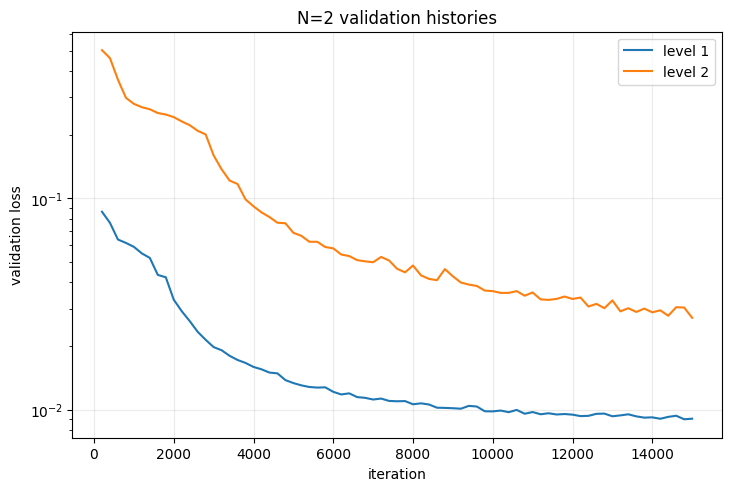

In [22]:
models2 = {
    1: singleton_model,
    2: n2_model,
}

n2_training_summary = training_summary(
    2,
    {
        1: singleton_training,
        2: n2_training,
    },
)
n2_monitoring = monitoring_diagnostics(
    2,
    models2,
    CFG.diagnostic_size,
)
n2_network = network_diagnostics(
    2,
    models2,
    CFG.diagnostic_size,
)
n2_constraints = constraint_diagnostics(
    2,
    models2,
    CFG.diagnostic_size,
)

display(n2_training_summary.round(6))
display(n2_monitoring.round(6))
display(n2_network.round(6))
display(n2_constraints.round(6))

n2_training_summary.to_csv(
    RESULTS_DIR / "N2_training_summary.csv",
    index=False,
)
n2_monitoring.to_csv(
    RESULTS_DIR / "N2_monitoring_diagnostics.csv",
    index=False,
)
n2_network.to_csv(
    RESULTS_DIR / "N2_network_diagnostics.csv",
    index=False,
)
n2_constraints.to_csv(
    RESULTS_DIR / "N2_constraint_diagnostics.csv",
    index=False,
)

plot_training_history(
    2,
    {
        1: singleton_training,
        2: n2_training,
    },
)

N3_level1                iter= 1000 val=6.3299e-02 stopped=3.878e-02 alive=2.832e-03 exit=4.514e-02 boundary=8.553e-03 terminal=1.117e-02 noninc=0.000e+00
N3_level1                iter= 2000 val=3.4255e-02 stopped=1.869e-02 alive=1.364e-03 exit=3.229e-02 boundary=5.206e-03 terminal=6.988e-03 noninc=0.000e+00
N3_level1                iter= 3000 val=1.9279e-02 stopped=1.311e-02 alive=8.333e-04 exit=2.861e-02 boundary=2.486e-03 terminal=7.361e-04 noninc=0.000e+00
N3_level1                iter= 4000 val=1.5189e-02 stopped=1.095e-02 alive=5.913e-04 exit=2.488e-02 boundary=1.250e-03 terminal=4.468e-04 noninc=0.000e+00
N3_level1                iter= 5000 val=1.3390e-02 stopped=9.970e-03 alive=4.915e-04 exit=2.291e-02 boundary=9.837e-04 terminal=9.612e-05 noninc=0.000e+00
N3_level1                iter= 6000 val=1.1609e-02 stopped=8.926e-03 alive=3.895e-04 exit=1.945e-02 boundary=4.358e-04 terminal=2.630e-04 noninc=0.000e+00
N3_level1                iter= 7000 val=1.0820e-02 stopped=8.209e-03 a

,time,MAE,RMSE,max_error
0,0.00,0.044075,0.049112,0.084795
1,0.50,0.031366,0.040491,0.079518
2,0.90,0.015323,0.028968,0.092777
3,0.95,0.004454,0.009198,0.027413


,N,level,best_iteration,best_validation_loss,runtime_min,stopped,living,exit,boundary,terminal,noninc,range
0,3,1,15000,0.009146,53.585348,0.007678,0.000194,0.013475,0.000072,0.000030,0.0,NaN
1,3,2,15000,0.025892,88.953265,0.016409,0.001505,0.033225,0.005292,0.000704,NaN,0.000276
2,3,3,15000,0.052668,119.222641,0.037896,0.001999,0.054998,0.007641,0.001389,NaN,0.000838


,N,level,hit_rate,no_hit_rate,mean_stop_fraction,mean_living_intervals
0,3,1,0.246826,0.753174,0.844812,32.792480
1,3,2,0.688721,0.311279,0.353107,13.693115
2,3,3,0.557617,0.442383,0.503040,19.510986


,N,level,domain_sample_fraction,field_min_on_domain,field_max_on_domain,range_violation_rate,value_symmetry_max_error,z_equivariance_max_error
0,3,1,1.000000,2.000000,2.994545,0.000000,0.0,0.0
1,3,2,0.437256,0.924818,2.758537,0.156337,0.0,0.0
2,3,3,0.600098,-0.136398,2.398488,0.110659,0.0,0.0


,N,level,boundary_MAE,boundary_RMSE,terminal_MAE,terminal_RMSE
0,3,1,0.007774,0.008487,0.002204,0.005608
1,3,2,0.038553,0.069290,0.016578,0.026908
2,3,3,0.056358,0.087003,0.029364,0.038644


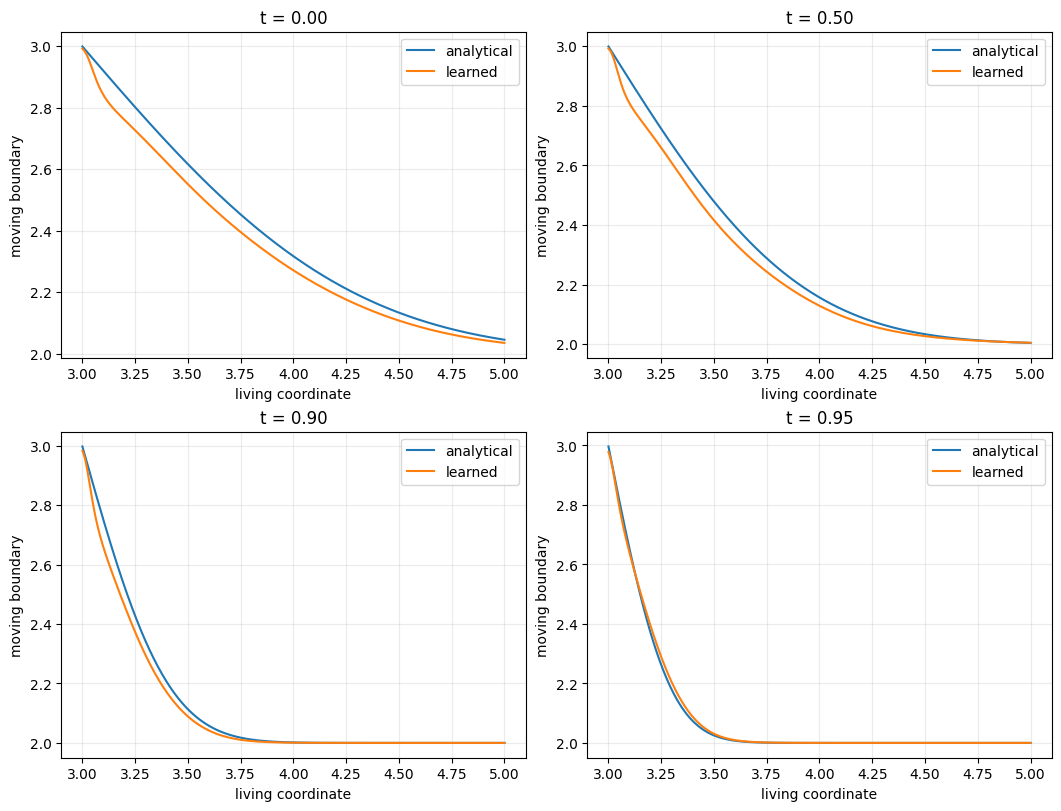

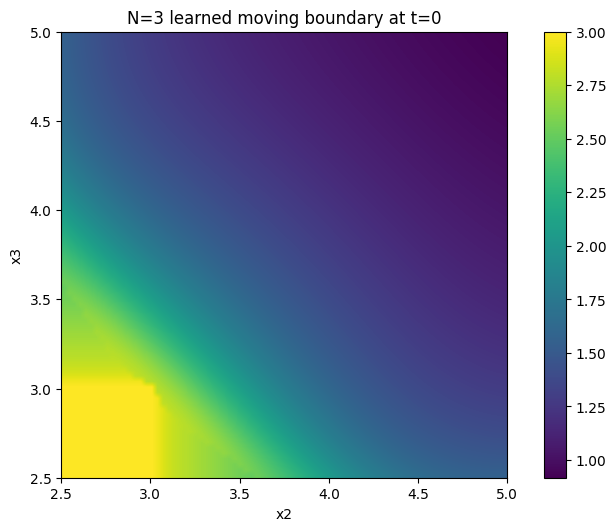

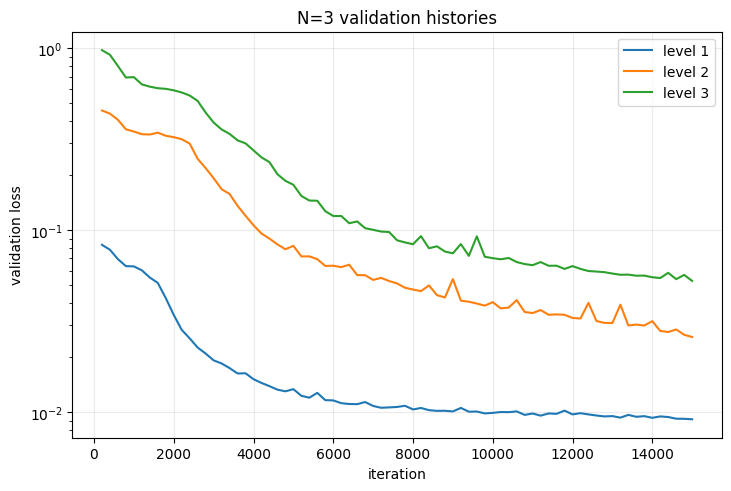

In [23]:
models3, training3 = train_general_cascade(
    3,
    SEED + 3_000,
)

n3_singleton_metrics = (
    general_singleton_metrics(
        3,
        models3,
    )
)
n3_singleton_metrics.to_csv(
    RESULTS_DIR / "N3_singleton_metrics.csv",
    index=False,
)

n3_training_summary = training_summary(
    3,
    training3,
)
n3_monitoring = monitoring_diagnostics(
    3,
    models3,
    CFG.diagnostic_size,
)
n3_network = network_diagnostics(
    3,
    models3,
    CFG.diagnostic_size,
)
n3_constraints = constraint_diagnostics(
    3,
    models3,
    CFG.diagnostic_size,
)

display(n3_singleton_metrics.round(6))
display(n3_training_summary.round(6))
display(n3_monitoring.round(6))
display(n3_network.round(6))
display(n3_constraints.round(6))

plot_general_singleton_boundary(
    3,
    models3,
)
plot_n3_boundary(
    models3
)
plot_training_history(
    3,
    training3,
)

n3_training_summary.to_csv(
    RESULTS_DIR / "N3_training_summary.csv",
    index=False,
)
n3_monitoring.to_csv(
    RESULTS_DIR / "N3_monitoring_diagnostics.csv",
    index=False,
)
n3_network.to_csv(
    RESULTS_DIR / "N3_network_diagnostics.csv",
    index=False,
)
n3_constraints.to_csv(
    RESULTS_DIR / "N3_constraint_diagnostics.csv",
    index=False,
)

,far_coordinate,max_boundary_hit_bound,field_MAE,field_RMSE,boundary_MAE,boundary_RMSE
0,4.0,0.317311,0.358356,0.428814,0.316543,0.324020
1,4.5,0.133614,0.153799,0.180490,0.106556,0.107048
2,5.0,0.045500,0.064153,0.073931,0.017340,0.020412


,far_coordinate,max_boundary_hit_bound,field_MAE,field_RMSE,boundary_MAE,boundary_RMSE
2,5.0,0.0455,0.064153,0.073931,0.01734,0.020412


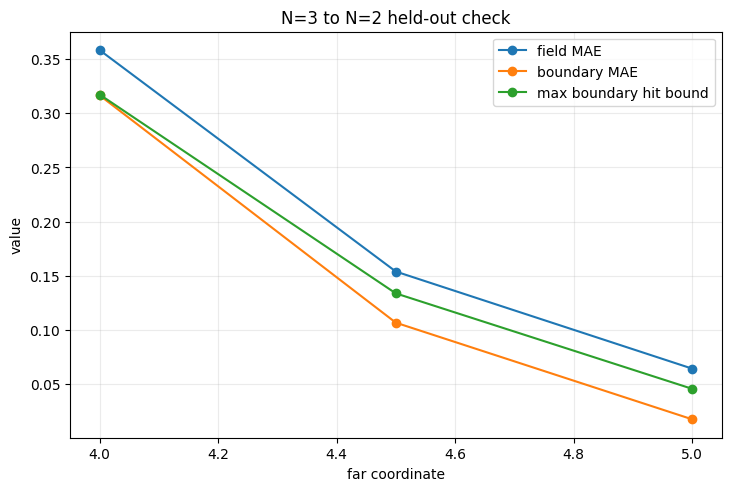

In [24]:
n3_to_n2_check = projection_sweep(
    higher_total=3,
    higher_models=models3,
    lower_total=2,
    lower_models=models2,
    far_values=(4.0, 4.5, 5.0),
    samples=CFG.projection_samples,
)

n3_to_n2_check.to_csv(
    RESULTS_DIR / "N3_to_N2_projection_check.csv",
    index=False,
)

display(n3_to_n2_check.round(6))

n3_principal_check = (
    n3_to_n2_check[
        n3_to_n2_check[
            "far_coordinate"
        ] == 5.0
    ]
)

display(n3_principal_check.round(6))

plot_projection_sweep(
    n3_to_n2_check,
    3,
    2,
)